# NanoInspect: Offline Visual Quality Inspection on the HP ZGX Nano

## Problem statement
At the end of a production line, someone must decide for every part: **ship it, scrap it, or have a person look again.** Today that decision is usually made in one of two ways, and both have problems:

1. **Human visual inspection** is slow, and fatigue makes it inconsistent. A missed defect (an *escape*) reaches the customer. A false reject throws away a good part.
2. **Cloud vision APIs** move every product image off the factory floor. That exposes product designs and process data, stops the line when the network drops, and adds per-image cost and round-trip latency that grow with line speed.

There is also a **data problem**: a new product line has hundreds of images of good parts and almost no images of defective ones, so ordinary supervised training is not possible.

**NanoInspect runs the complete inspection loop on one HP ZGX Nano, with no network connection:**
- A vision model trained **only on images of good parts** (plus synthetic defects we generate) scores each part.
- A local open-weight LLM (**Qwen2.5-3B-Instruct, inference only, not fine-tuned**) runs the reinspection, severity, SOP-lookup, and history tools, then writes an operator note.
- **Deterministic rules make the final `accept` / `reject` / `manual_review` decision.** Uncertain parts go to a human; nothing is silently accepted.
- Every decision is written as a JSON audit record together with its evidence (scores, reinspection views, Grad-CAM).

## Claims and where they are proven
| Claim | Evidence |
|---|---|
| Catches real defects it never saw in training | Section 4: 83 real MVTec test images; S5: escape rate and false-reject rate under the decision policy |
| Fast enough for a production line | S2, S3: p50/p95/p99 latency, throughput vs. batch size, fp32 vs. bf16 |
| Holds up under sustained load | S6: soak test tracking temperature, SM clock, power, throttle flags, and throughput over time |
| Robust to real camera conditions | S4: brightness, contrast, blur, JPEG, rotation, noise, crop, low resolution |
| Agent output is reliable | S7: report-validity, LLM-fallback, and guardrail-override rates on 24 images |
| Truly offline | S8: every outbound network connection blocked while the full pipeline runs |
| Fails safe | S9: corrupt, missing, or out-of-distribution images and malformed LLM output never produce `accept` |

## What was trained and what was not
- **ResNet-18 (ImageNet-pretrained):** partially fine-tuned on the Nano. Only `layer4` and the head are trained (~8.4M parameters), using ~80% of the 209 good training images plus synthetic defects. The other 20% are held out for validation.
- **Qwen2.5-3B-Instruct:** **not fine-tuned.** It is used for inference only.
- **Scope:** one MVTec AD category (`bottle`). This is a proof of concept, not a production-validated system.

## 1. Dataset setup

Download MVTec AD from the official page: https://www.mvtec.com/research-teaching/datasets/mvtec-ad

Extract the archive so that the folder structure is:
```text
mvtec_anomaly_detection/
  bottle/
    train/good/
    test/good/
    test/broken_large/
    ground_truth/...
```

For Google Colab, upload or mount the extracted folder. For the HP Nano, set `DATA_ROOT` to the local extracted directory.

In [1]:
# Install dependencies if needed. Run once.
%pip install -q torch torchvision scikit-learn matplotlib pandas pillow tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import tarfile
import os

# Directory containing the MVTec category archives
ARCHIVE_DIR = Path("/home/hp14/jupyterlab/content")

# Available complete archives
ARCHIVES = {
    "bottle": ARCHIVE_DIR / "bottle.tar.xz",
    "zipper": ARCHIVE_DIR / "zipper.tar.xz",
    "toothbrush": ARCHIVE_DIR / "toothbrush.tar.xz",
    "grid": ARCHIVE_DIR / "grid.tar.xz",
    "transistor": ARCHIVE_DIR / "transistor.tar.xz",
    "metal_nut": ARCHIVE_DIR / "metal_nut.tar.xz",
    "tile": ARCHIVE_DIR / "tile.tar.xz",
    "screw": ARCHIVE_DIR / "screw.tar.xz",
    "cable": ARCHIVE_DIR / "cable.tar.xz",
    "hazelnut": ARCHIVE_DIR / "hazelnut.tar.xz",
    "capsule": ARCHIVE_DIR / "capsule.tar.xz",
    "leather": ARCHIVE_DIR / "leather.tar.xz",
    "wood": ARCHIVE_DIR / "wood.tar.xz",
    "pill": ARCHIVE_DIR / "pill.tar.xz",
}

# Select one category
CATEGORY = "bottle"

# Where the archive will be extracted
DATA_ROOT = Path("/home/hp14/jupyterlab/mvtec_anomaly_detection")

IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 0  # in-process loading; worker processes print shutdown errors inside Jupyter
VAL_FRACTION = 0.2  # share of train/good held out for checkpoint selection
EPOCHS = 8


def extract_category_archive(category):
    archive_path = ARCHIVES[category]

    if not archive_path.exists():
        raise FileNotFoundError(
            f"Archive not found: {archive_path}"
        )

    category_root = DATA_ROOT / category

    # Skip extraction if already extracted
    if (category_root / "train" / "good").exists():
        print("Dataset already extracted.")
        return category_root

    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {archive_path}...")

    with tarfile.open(archive_path, mode="r:*") as tar:
        tar.extractall(DATA_ROOT)

    # Expected structure:
    # /mvtec_anomaly_detection/bottle/train/good
    if (DATA_ROOT / category / "train" / "good").exists():
        return DATA_ROOT / category

    # Alternative structure:
    # /mvtec_anomaly_detection/train/good
    if (DATA_ROOT / "train" / "good").exists():
        return DATA_ROOT

    # Search recursively for train/good
    for train_folder in DATA_ROOT.rglob("train"):
        if (train_folder / "good").exists():
            return train_folder.parent

    raise FileNotFoundError(
        f"Could not find train/good after extracting {archive_path}"
    )


CATEGORY_ROOT = extract_category_archive(CATEGORY)

print("\nDataset location:", CATEGORY_ROOT)
print(
    "Training images:",
    len(list((CATEGORY_ROOT / "train" / "good").glob("*")))
)
print(
    "Testing images:",
    len(list((CATEGORY_ROOT / "test").glob("*/*")))
)

Dataset already extracted.

Dataset location: /home/hp14/jupyterlab/mvtec_anomaly_detection/bottle
Training images: 209
Testing images: 83


In [3]:
from pathlib import Path
import os, random, time, copy
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.13.0+cu130


## 2. Create normal and synthetic-defect samples

The model sees normal images with label `0` and synthetic defects with label `1`. Synthetic defects are only used to teach the classifier what an abnormal visual pattern can look like; the final test set contains real defects.

Normal training images: 168
Validation images: 82 (41 normal + 41 synthetic-defect)
Real test images: 83
Leakage check passed: 0 identical files between train/val and test.


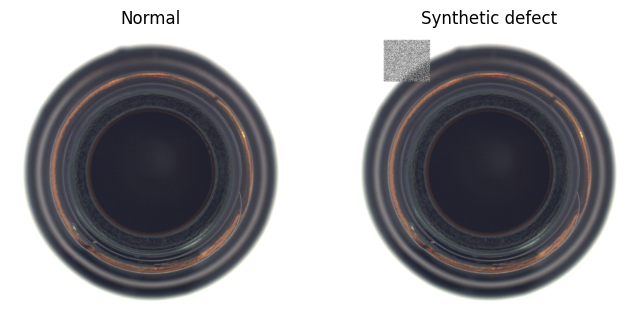

In [4]:
# Datasets: synthetic-defect training set, fixed validation set, real MVTec test set, leakage check.
import hashlib

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.bmp'}
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def add_synthetic_defect(image):
    """Add a random scratch, patch, or noisy region to a PIL image."""
    image = image.convert('RGB').copy()
    w, h = image.size
    draw = ImageDraw.Draw(image, 'RGBA')
    defect_type = random.choice(['rectangle', 'scratch', 'noise'])
    x1, y1 = random.randint(0, int(w * .65)), random.randint(0, int(h * .65))
    x2, y2 = random.randint(x1 + 8, min(w, x1 + int(w * .35))), random.randint(y1 + 8, min(h, y1 + int(h * .35)))
    if defect_type == 'rectangle':
        color = random.choice([(255, 30, 30, 190), (20, 20, 20, 210), (255, 220, 0, 180)])
        draw.rectangle([x1, y1, x2, y2], fill=color)
    elif defect_type == 'scratch':
        for _ in range(random.randint(2, 5)):
            draw.line([x1, y1 + random.randint(0, max(1, y2-y1)), x2, y1 + random.randint(0, max(1, y2-y1))], fill=(255, 255, 255, 230), width=random.randint(1, 3))
    else:
        patch = Image.effect_noise((max(2, x2-x1), max(2, y2-y1)), random.randint(80, 180)).convert('L').convert('RGBA')
        patch.putalpha(170)
        image.paste(patch, (x1, y1), patch)
    return image

class SyntheticMVTecDataset(Dataset):
    def __init__(self, paths, transform, anomaly_probability=0.5):
        self.paths = paths
        self.transform = transform
        self.anomaly_probability = anomaly_probability
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        is_anomaly = random.random() < self.anomaly_probability
        if is_anomaly: image = add_synthetic_defect(image)
        return self.transform(image), torch.tensor(int(is_anomaly), dtype=torch.long)

class FixedValidationDataset(Dataset):
    """Each held-out normal image appears twice: clean (label 0) and with a seeded
    synthetic defect (label 1). The set is identical every epoch."""
    def __init__(self, paths, transform, seed=SEED):
        rng_state = random.getstate(); random.seed(seed)
        self.items = []
        for p in paths:
            image = Image.open(p).convert('RGB')
            self.items.append((image, 0))
            self.items.append((add_synthetic_defect(image), 1))
        random.setstate(rng_state)
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        image, label = self.items[idx]
        return self.transform(image), torch.tensor(label, dtype=torch.long)

class RealMVTecTestDataset(Dataset):
    def __init__(self, category_root, transform):
        self.items = []
        for defect_dir in sorted((category_root / 'test').iterdir()):
            if defect_dir.is_dir():
                label = 0 if defect_dir.name == 'good' else 1
                for p in sorted(defect_dir.glob('*')):
                    if p.suffix.lower() in IMAGE_SUFFIXES:
                        self.items.append((p, label, defect_dir.name))
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, label, defect_name = self.items[idx]
        image = Image.open(p).convert('RGB')
        return self.transform(image), torch.tensor(label), str(p), defect_name

# Fixed, seeded split of the normal training images
all_normal_paths = sorted(p for p in (CATEGORY_ROOT / 'train' / 'good').glob('*') if p.suffix.lower() in IMAGE_SUFFIXES)
shuffled = all_normal_paths.copy(); random.Random(SEED).shuffle(shuffled)
n_val = int(len(shuffled) * VAL_FRACTION)
val_paths, normal_paths = sorted(shuffled[:n_val]), sorted(shuffled[n_val:])

train_ds = SyntheticMVTecDataset(normal_paths, train_transform)
val_ds = FixedValidationDataset(val_paths, eval_transform)
test_ds = RealMVTecTestDataset(CATEGORY_ROOT, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Leakage check: no test image may appear (by content hash) in train or validation
def file_md5(p): return hashlib.md5(Path(p).read_bytes()).hexdigest()
train_hashes = {file_md5(p) for p in all_normal_paths}
test_hashes = {file_md5(p) for p, _, _ in test_ds.items}
assert not set(val_paths) & set(normal_paths), 'Validation overlaps training'
assert not train_hashes & test_hashes, f'{len(train_hashes & test_hashes)} test images also appear in train/good'

print('Normal training images:', len(normal_paths))
print('Validation images:', len(val_ds), f'({len(val_paths)} normal + {len(val_paths)} synthetic-defect)')
print('Real test images:', len(test_ds))
print('Leakage check passed: 0 identical files between train/val and test.')

# Preview a normal image and a synthetic defect
sample = Image.open(normal_paths[0]).convert('RGB')
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample); ax[0].set_title('Normal'); ax[0].axis('off')
ax[1].imshow(add_synthetic_defect(sample)); ax[1].set_title('Synthetic defect'); ax[1].axis('off')
plt.show()

## 3. Fine-tune a pretrained ResNet-18 locally

The ImageNet-pretrained ResNet-18 provides a useful visual feature extractor. We first freeze most layers and fine-tune the final convolutional block (`layer4`) plus the new binary classification head. This reduces training time and memory use on the edge device.

In [5]:
def build_model():
    try:
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        print('Loaded ImageNet-pretrained ResNet-18.')
    except Exception as exc:
        print('Pretrained weights unavailable; using random initialization:', exc)
        model = models.resnet18(weights=None)
    for p in model.parameters(): p.requires_grad = False
    for p in model.layer4.parameters(): p.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(0.25),
        nn.Linear(model.fc.in_features, 2)
    )
    return model.to(DEVICE)

model = build_model()
criterion = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print('Trainable parameters:', sum(p.numel() for p in trainable_params))

Loaded ImageNet-pretrained ResNet-18.
Trainable parameters: 8394754


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 01/8 | loss=0.5938 | train acc=0.6250 | val AUC=0.8697 | val acc=0.7317


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 02/8 | loss=0.4352 | train acc=0.8214 | val AUC=0.9167 | val acc=0.8049


  0%|          | 0/11 [00:00<?, ?it/s]

...

Epoch 06/8 | loss=0.3917 | train acc=0.8036 | val AUC=0.9435 | val acc=0.8902


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 07/8 | loss=0.3759 | train acc=0.8571 | val AUC=0.9429 | val acc=0.8902


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 08/8 | loss=0.4518 | train acc=0.8155 | val AUC=0.9477 | val acc=0.8902
Training time: 0.46 minutes | selected epoch 8 (val AUC=0.9477)


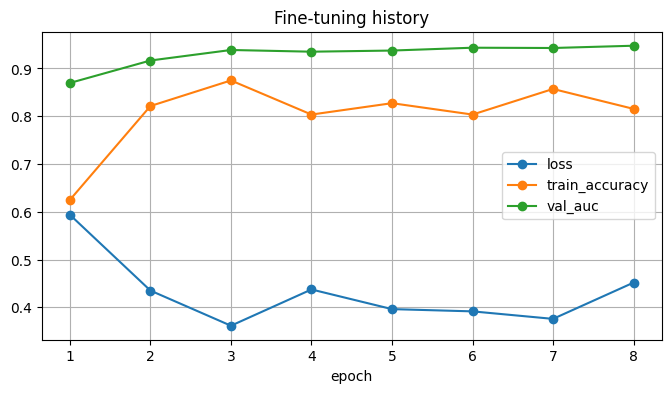

In [6]:
# Fine-tune; keep the epoch with the best validation ROC-AUC.
def train_one_epoch(model, loader):
    model.train(); running_loss = 0.0; correct = 0; total = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += x.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate_validation(model, loader):
    model.eval(); labels, scores = [], []
    for x, y in loader:
        scores.extend(torch.softmax(model(x.to(DEVICE)), 1)[:, 1].cpu().tolist()); labels.extend(y.tolist())
    labels, scores = np.array(labels), np.array(scores)
    return roc_auc_score(labels, scores), accuracy_score(labels, scores >= 0.5), scores[labels == 0]

history = []
best_state = None; best_key = (-1, -1)
start_train = time.perf_counter()
for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model, train_loader)
    scheduler.step()
    val_auc, val_acc, val_normal_scores = evaluate_validation(model, val_loader)
    history.append({'epoch': epoch + 1, 'loss': loss, 'train_accuracy': acc, 'val_auc': val_auc, 'val_accuracy': val_acc})
    if (val_auc, val_acc) > best_key:
        best_key = (val_auc, val_acc); best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict()); VAL_NORMAL_SCORES = val_normal_scores
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | loss={loss:.4f} | train acc={acc:.4f} | val AUC={val_auc:.4f} | val acc={val_acc:.4f}')
train_seconds = time.perf_counter() - start_train
model.load_state_dict(best_state)
print(f'Training time: {train_seconds/60:.2f} minutes | selected epoch {best_epoch} (val AUC={best_key[0]:.4f})')
pd.DataFrame(history).plot(x='epoch', y=['loss', 'train_accuracy', 'val_auc'], marker='o', figsize=(8, 4), title='Fine-tuning history'); plt.grid(); plt.show()

## 4. Evaluate on real MVTec defects

This is the important evaluation: the model was trained using normal images and synthetic defects, but the metrics below are calculated on the real MVTec test images.

In [7]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval(); y_true, y_pred, y_score, paths, names = [], [], [], [], []
    latency = []
    for x, y, p, n in loader:
        x = x.to(DEVICE)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter(); logits = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        latency.append((time.perf_counter() - t0) / x.size(0))
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_true.extend(y.numpy().tolist()); y_pred.extend((prob >= 0.5).astype(int).tolist()); y_score.extend(prob.tolist())
        paths.extend(list(p)); names.extend(list(n))
    return np.array(y_true), np.array(y_pred), np.array(y_score), paths, names, float(np.mean(latency) * 1000)

y_true, y_pred, y_score, test_paths, defect_names, avg_latency_ms = predict_loader(model, test_loader)
metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_score),
    # measured at batch 16 and divided per image; true batch-1 latency is measured in S2
    'avg_ms_per_image_at_batch16': avg_latency_ms,
}
print(pd.Series(metrics).round(4))
print('\nClassification report:\n', classification_report(y_true, y_pred, target_names=['normal', 'anomaly'], zero_division=0))
print('Confusion matrix:\n', confusion_matrix(y_true, y_pred))

accuracy                       0.9639
precision                      0.9839
recall                         0.9683
f1                             0.9760
roc_auc                        0.9929
avg_ms_per_image_at_batch16    0.3537
dtype: float64

Classification report:
               precision    recall  f1-score   support

      normal       0.90      0.95      0.93        20
     anomaly       0.98      0.97      0.98        63

    accuracy                           0.96        83
   macro avg       0.94      0.96      0.95        83
weighted avg       0.96      0.96      0.96        83

Confusion matrix:
 [[19  1]
 [ 2 61]]


In [8]:
# Metrics by real defect type
results = pd.DataFrame({
    'path': test_paths, 'defect_type': defect_names, 'true_label': y_true,
    'predicted_label': y_pred, 'anomaly_probability': y_score
})
summary = results.groupby('defect_type').agg(
    samples=('true_label', 'size'),
    mean_anomaly_probability=('anomaly_probability', 'mean'),
    predicted_anomaly_rate=('predicted_label', 'mean')
).sort_values('mean_anomaly_probability', ascending=False)
display(summary.round(3))
results.to_csv(f'{CATEGORY}_predictions.csv', index=False)
torch.save({'model_state_dict': model.state_dict(), 'category': CATEGORY, 'image_size': IMAGE_SIZE, 'metrics': metrics}, f'{CATEGORY}_resnet18_finetuned.pt')
print('Saved predictions and model checkpoint.')

,samples,mean_anomaly_probability,predicted_anomaly_rate
defect_type,,,
broken_large,20,0.994,1.000
broken_small,22,0.924,1.000
contamination,21,0.828,0.905
good,20,0.250,0.050


Saved predictions and model checkpoint.


## 5. Visualize an anomaly decision

The heatmap below uses Grad-CAM from the fine-tuned ResNet-18. It shows which image regions contributed to the anomaly prediction.

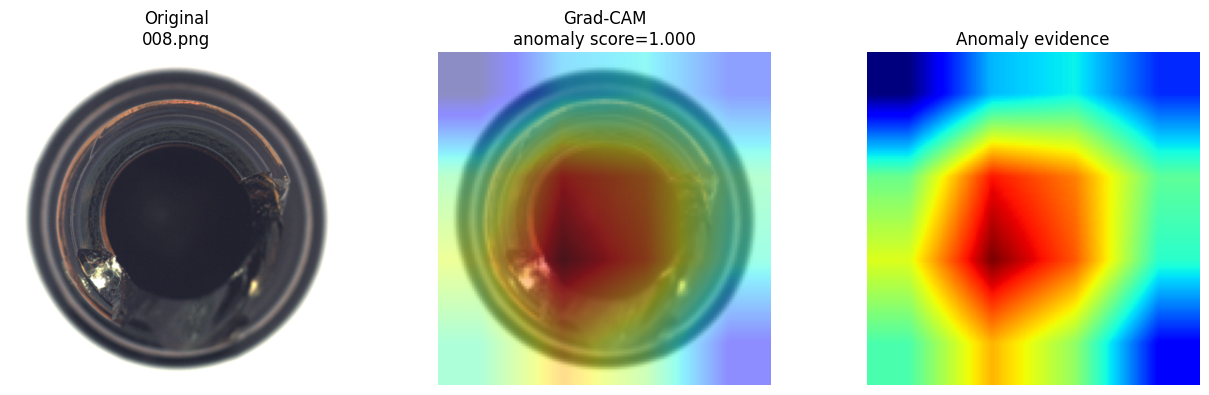

In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.activations = None; self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    def _save_activation(self, module, inp, out): self.activations = out
    def _save_gradient(self, module, grad_in, grad_out): self.gradients = grad_out[0]
    def __call__(self, x, class_idx=1):
        self.model.zero_grad(set_to_none=True); logits = self.model(x)
        logits[:, class_idx].sum().backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True).relu()
        cam = torch.nn.functional.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy(); cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return logits.softmax(1)[0, class_idx].item(), cam

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1); std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1,2,0).numpy()

model.eval()
cam_generator = GradCAM(model, model.layer4[-1])
display_idx = int(np.argmax(y_score))
raw = Image.open(test_paths[display_idx]).convert('RGB')
x, _, _, _ = test_ds[display_idx]
x_batch = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
score, cam = cam_generator(x_batch, class_idx=1)
rgb = denormalize(x)
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(raw); ax[0].set_title(f'Original\n{Path(test_paths[display_idx]).name}'); ax[0].axis('off')
ax[1].imshow(rgb); ax[1].imshow(cam, cmap='jet', alpha=0.45); ax[1].set_title(f'Grad-CAM\nanomaly score={score:.3f}'); ax[1].axis('off')
ax[2].imshow(cam, cmap='jet'); ax[2].set_title('Anomaly evidence'); ax[2].axis('off')
plt.tight_layout(); plt.show()

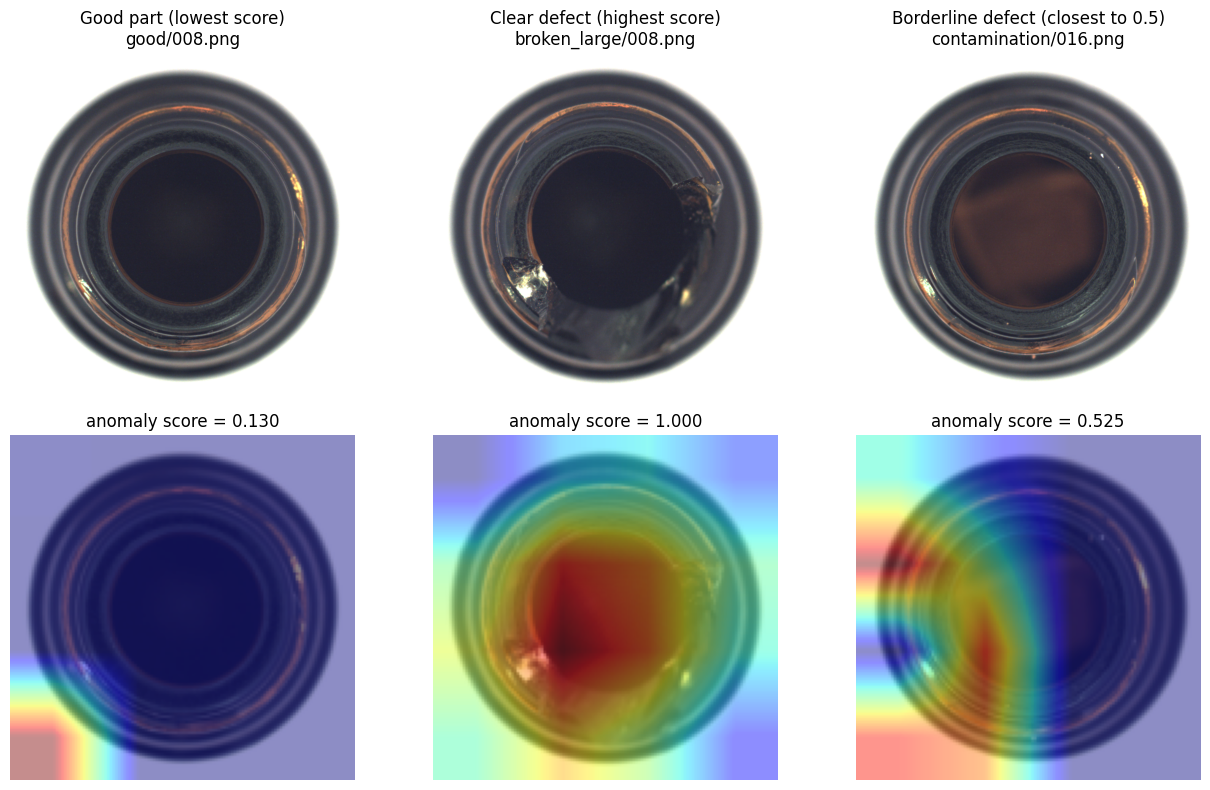

In [10]:
# Grad-CAM on three cases chosen by rule (not hand-picked):
# the most confident good part, the most confident defect, and the defect closest to the 0.5 threshold.
good_idx = [i for i, t in enumerate(y_true) if t == 0]
bad_idx = [i for i, t in enumerate(y_true) if t == 1]
cases = {
    'Good part (lowest score)': min(good_idx, key=lambda i: y_score[i]),
    'Clear defect (highest score)': max(bad_idx, key=lambda i: y_score[i]),
    'Borderline defect (closest to 0.5)': min(bad_idx, key=lambda i: abs(y_score[i] - 0.5)),
}
fig, ax = plt.subplots(2, 3, figsize=(13, 8))
for col, (title, idx) in enumerate(cases.items()):
    x, _, _, _ = test_ds[idx]
    score, cam = cam_generator(x.unsqueeze(0).to(DEVICE).requires_grad_(True), class_idx=1)
    ax[0, col].imshow(Image.open(test_paths[idx]).convert('RGB'))
    ax[0, col].set_title(f'{title}\n{defect_names[idx]}/{Path(test_paths[idx]).name}'); ax[0, col].axis('off')
    ax[1, col].imshow(denormalize(x)); ax[1, col].imshow(cam, cmap='jet', alpha=0.45)
    ax[1, col].set_title(f'anomaly score = {score:.3f}'); ax[1, col].axis('off')
plt.tight_layout(); plt.savefig(f'{CATEGORY}_gradcam_three_cases.png', dpi=120); plt.show()
DEMO_CASES = {title: test_paths[idx] for title, idx in cases.items()}

## 6. Test one new image locally

Set `SINGLE_IMAGE_PATH` to an image from the MVTec test folder or a camera snapshot.

In [11]:
SINGLE_IMAGE_PATH = test_paths[display_idx]  # Replace with your own image path

# Latency of this call: load + preprocess + inference.
def predict_image(image_path):
    t0 = time.perf_counter()
    image = Image.open(image_path).convert('RGB')
    x = eval_transform(image).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probability = torch.softmax(model(x), dim=1)[0, 1].item()  # .item() waits for the GPU
    latency_ms = (time.perf_counter() - t0) * 1000
    label = 'ANOMALOUS' if probability >= 0.5 else 'NORMAL'
    return {'path': str(image_path), 'prediction': label, 'anomaly_probability': round(probability, 4), 'end_to_end_latency_ms': round(latency_ms, 2)}

print(predict_image(SINGLE_IMAGE_PATH))

{'path': '/home/hp14/jupyterlab/mvtec_anomaly_detection/bottle/test/broken_large/008.png', 'prediction': 'ANOMALOUS', 'anomaly_probability': 1.0, 'end_to_end_latency_ms': 17.77}


## 7. What to present

**Problem (30 s):** Every part at the end of the line needs a ship/scrap/recheck decision. Human inspectors get tired, and cloud AI sends every product image off-site and stops working when the network drops. New product lines also have almost no defect images to train on.

**Approach (60 s):** ResNet-18 learns from good parts plus synthetic defects, then is tested on *real* defects. Qwen2.5-3B, running locally, orchestrates reinspection, severity, and SOP tools and writes the operator note. Deterministic rules make the final decision, and uncertain parts go to `manual_review`.

**Evidence slides:**
1. Real-defect metrics: ROC-AUC, recall, escape rate and false-reject rate under the decision policy (Section 4, S5).
2. Edge benchmark table (S11): p50/p95 latency, throughput, peak memory, soak-test stability.
3. Robustness chart (S4) and the failure-mode table (S9).
4. Offline proof (S8): pipeline runs with the network blocked; 0 outbound connections attempted.
5. Live demo: one good part (accept), one clear defect (reject), one borderline part (manual_review).

**Claims to avoid:** "Qwen was fine-tuned" (it was not). "98.9% accuracy" (98.9% is ROC-AUC). "Production-ready." Presenting the demo SOP or batch history as a real factory database.

**Limitations:** One category. Synthetic defects do not cover every real defect type. The test set has only 20 good images, so false-reject rates are coarse.

In [12]:
# Install the local language-model dependencies for the inspection agent.
%pip install -q "transformers>=4.45" accelerate sentencepiece huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [13]:
# Check that the trained ResNet baseline and test image are available.
required_objects = [
    "model",
    "DEVICE",
    "CATEGORY",
    "eval_transform",
    "test_paths",
    "y_score",
    "SINGLE_IMAGE_PATH",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

print("Missing objects:", missing_objects)
print("Category:", CATEGORY if "CATEGORY" in globals() else "Not defined")
print("Vision device:", DEVICE if "DEVICE" in globals() else "Not defined")
print("Number of test images:", len(test_paths) if "test_paths" in globals() else 0)

assert not missing_objects, (
    "Run the original notebook cells from the beginning before continuing."
)
assert len(test_paths) > 0, "No MVTec test images were found."

print("Vision baseline check passed.")

Missing objects: []
Category: bottle
Vision device: cuda
Number of test images: 83
Vision baseline check passed.


In [14]:
# Load Qwen2.5-3B-Instruct locally, entirely on the GPU (no CPU offload).
# Loads from the local Hugging Face cache first, so the cell also works offline.
import os, subprocess
from transformers import AutoModelForCausalLM, AutoTokenizer

LLM_ID = os.environ.get("NANOINSPECT_LLM_ID", "Qwen/Qwen2.5-3B-Instruct")
HF_TOKEN = os.environ.get("HF_TOKEN")

# Warn if other processes are holding GPU memory (vLLM, other notebooks...)
other_gpu_apps = subprocess.run(
    ["nvidia-smi", "--query-compute-apps=pid,process_name", "--format=csv,noheader"],
    capture_output=True, text=True
).stdout.strip().splitlines()
other_gpu_apps = [a for a in other_gpu_apps if a and not a.startswith(str(os.getpid()))]
if other_gpu_apps:
    print("WARNING: other GPU processes are running and share the Nano's memory:")
    for a in other_gpu_apps: print("   ", a)

model_kwargs = {}
if HF_TOKEN: model_kwargs["token"] = HF_TOKEN
if DEVICE.type == "cuda":
    model_kwargs["device_map"] = {"": 0}  # everything on GPU 0, no CPU offload
    model_kwargs["dtype"] = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

def load_from_cache_or_hub(cls, **kwargs):
    try:
        return cls.from_pretrained(LLM_ID, local_files_only=True, **kwargs)
    except OSError:
        print(f"{LLM_ID} not in local cache; downloading once from Hugging Face.")
        return cls.from_pretrained(LLM_ID, **kwargs)

t0 = time.perf_counter()
llm_tokenizer = load_from_cache_or_hub(AutoTokenizer, **({"token": HF_TOKEN} if HF_TOKEN else {}))
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token
llm_model = load_from_cache_or_hub(AutoModelForCausalLM, **model_kwargs)
llm_model.eval()
LLM_LOAD_SECONDS = time.perf_counter() - t0

param_devices = sorted({str(p.device) for p in llm_model.parameters()})
print("Loaded LLM:", LLM_ID)
print("Parameter devices:", param_devices)
print(f"LLM weights in memory: {llm_model.get_memory_footprint() / 1e9:.2f} GB | load time: {LLM_LOAD_SECONDS:.1f} s")
assert param_devices == ["cuda:0"] or DEVICE.type != "cuda", "Some LLM layers are not on the GPU"

    2783411, /home/hp14/jupyterlab/.venv/bin/python3


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loaded LLM: Qwen/Qwen2.5-3B-Instruct
Parameter devices: ['cuda:0']
LLM weights in memory: 6.17 GB | load time: 40.3 s


In [15]:
# Verify that the local LLM can generate a response without using a cloud API.
import json
import re

def generate_local_llm(messages, max_new_tokens=160):
    prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    input_device = (
        llm_model
        .get_input_embeddings()
        .weight
        .device
    )

    inputs = {
        key: value.to(input_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        generated = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llm_tokenizer.pad_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]
    new_tokens = generated[0][prompt_length:]

    return llm_tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()


def parse_json_object(text):
    match = re.search(
        r"\{.*\}",
        str(text),
        flags=re.DOTALL
    )

    if not match:
        return {}

    try:
        parsed = json.loads(match.group(0))
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}


test_messages = [
    {
        "role": "system",
        "content": (
            "Return JSON only with keys status and message."
        )
    },
    {
        "role": "user",
        "content": (
            "Confirm that the local inspection agent is ready."
        )
    }
]

test_llm_output = generate_local_llm(
    test_messages,
    max_new_tokens=60
)

print("Local LLM output:")
print(test_llm_output)

assert len(test_llm_output) > 0
print("Local LLM generation check passed.")

Local LLM output:
{
  "status": "success",
  "message": "Local inspection agent is confirmed to be ready."
}
Local LLM generation check passed.


In [16]:
# Define local tools for reinspection, SOP lookup, batch history, and severity.
from PIL import ImageEnhance

def infer_pil_image(image, source_name):
    image = image.convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.eval()

    with torch.inference_mode():
        logits = model(tensor)
        probability = torch.softmax(
            logits,
            dim=1
        )[0, 1].item()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    latency_ms = (
        time.perf_counter() - start_time
    ) * 1000

    label = (
        "ANOMALOUS"
        if probability >= 0.5
        else "NORMAL"
    )

    return {
        "source": str(source_name),
        "prediction": label,
        "anomaly_probability": round(
            float(probability),
            4
        ),
        "latency_ms": round(
            float(latency_ms),
            3
        )
    }


def run_vision_inference(image_path):
    image = Image.open(image_path).convert("RGB")
    return infer_pil_image(image, image_path)


def tool_reinspect_image(image_path):
    image = Image.open(image_path).convert("RGB")

    width, height = image.size
    crop_side = int(min(width, height) * 0.75)

    left = max((width - crop_side) // 2, 0)
    top = max((height - crop_side) // 2, 0)

    center_crop = image.crop(
        (
            left,
            top,
            left + crop_side,
            top + crop_side
        )
    )

    contrast_view = ImageEnhance.Contrast(
        image
    ).enhance(1.35)

    views = [
        infer_pil_image(image, "original"),
        infer_pil_image(center_crop, "center_crop"),
        infer_pil_image(
            contrast_view,
            "contrast_enhanced"
        )
    ]

    probabilities = [
        item["anomaly_probability"]
        for item in views
    ]

    mean_probability = float(
        np.mean(probabilities)
    )

    anomaly_votes = sum(
        item["prediction"] == "ANOMALOUS"
        for item in views
    )

    return {
        "tool": "reinspect_image",
        "views": views,
        "mean_anomaly_probability": round(
            mean_probability,
            4
        ),
        "anomaly_votes": anomaly_votes,
        "agreement": round(
            anomaly_votes / len(views),
            3
        )
    }


SOP_LIBRARY = {
    "default": {
        "low": (
            "Release the item after a quick visual check."
        ),
        "medium": (
            "Hold the item and perform a second inspection."
        ),
        "high": (
            "Reject the item and inspect the current batch."
        )
    },
    "bottle": {
        "low": (
            "Release the bottle after checking the surface."
        ),
        "medium": (
            "Hold the bottle and inspect the cap, label, and surface."
        ),
        "high": (
            "Reject the bottle and inspect the current bottle batch."
        )
    }
}


def tool_lookup_defect_sop(category, severity):
    policy = SOP_LIBRARY.get(
        str(category),
        SOP_LIBRARY["default"]
    )

    return {
        "tool": "lookup_defect_sop",
        "category": str(category),
        "severity": str(severity),
        "recommended_action": policy.get(
            str(severity),
            policy["medium"]
        )
    }


BATCH_HISTORY = {
    "DEMO-BATCH-001": {
        "items_inspected": 20,
        "anomalies_found": 2,
        "previous_pattern": (
            "occasional surface variation"
        )
    },
    "DEMO-BATCH-002": {
        "items_inspected": 20,
        "anomalies_found": 0,
        "previous_pattern": (
            "no repeated defect pattern"
        )
    }
}


def tool_check_quality_history(batch_id):
    history = BATCH_HISTORY.get(
        str(batch_id),
        {
            "items_inspected": 0,
            "anomalies_found": 0,
            "previous_pattern": (
                "no local history available"
            )
        }
    )

    return {
        "tool": "check_quality_history",
        "batch_id": str(batch_id),
        **history
    }


# Decision policy. One source of truth for severity and the final decision.
# review_at is set from the *validation* normals (not the test set): the score below which
# 95% of held-out good parts fall, clipped to [0.15, 0.5]. Lower = fewer escapes, more manual reviews.
_val_normals = globals().get("VAL_NORMAL_SCORES")
DECISION_POLICY = {
    "reject_at": 0.85,
    "review_at": float(np.clip(np.quantile(_val_normals, 0.95), 0.15, 0.5)) if _val_normals is not None else 0.30,
    "min_agreement_for_reject": 0.66,
}
print("Decision policy:", DECISION_POLICY)


# Severity uses DECISION_POLICY.
#   accept vs. review is decided on the original view: the crop/contrast reinspection views
#   raise the score of good parts too (see S4), so they must not push good parts into review.
#   reject needs confirmation: high original score AND the reinspection views agree.
#   A high score that reinspection does not confirm goes to manual review.
def tool_calculate_severity(
    initial_evidence,
    reinspection_result
):
    initial_probability = float(initial_evidence["anomaly_probability"])
    repeated_probability = float(reinspection_result.get("mean_anomaly_probability", initial_probability))
    agreement = float(reinspection_result.get("agreement", 0.0))

    if (
        initial_probability >= DECISION_POLICY["reject_at"]
        and repeated_probability >= DECISION_POLICY["reject_at"]
        and agreement >= DECISION_POLICY["min_agreement_for_reject"]
    ):
        severity = "high"
    elif initial_probability >= DECISION_POLICY["review_at"]:
        severity = "medium"
    else:
        severity = "low"

    return {
        "tool": "calculate_severity",
        "severity": severity,
        "initial_probability": round(initial_probability, 4),
        "reinspection_probability": round(repeated_probability, 4),
        "view_agreement": round(agreement, 3)
    }

Decision policy: {'reject_at': 0.85, 'review_at': 0.5, 'min_agreement_for_reject': 0.66}


In [17]:
# Check the deterministic local tools before involving the language model.
tool_test_path = str(SINGLE_IMAGE_PATH)

initial_tool_output = run_vision_inference(
    tool_test_path
)

reinspection_tool_output = tool_reinspect_image(
    tool_test_path
)

severity_tool_output = tool_calculate_severity(
    initial_tool_output,
    reinspection_tool_output
)

sop_tool_output = tool_lookup_defect_sop(
    CATEGORY,
    severity_tool_output["severity"]
)

history_tool_output = tool_check_quality_history(
    "DEMO-BATCH-001"
)

tool_test_output = {
    "initial": initial_tool_output,
    "reinspection": reinspection_tool_output,
    "severity": severity_tool_output,
    "sop": sop_tool_output,
    "quality_history": history_tool_output
}

print(json.dumps(tool_test_output, indent=2))

assert reinspection_tool_output["tool"] == (
    "reinspect_image"
)

assert sop_tool_output["tool"] == (
    "lookup_defect_sop"
)

assert history_tool_output["tool"] == (
    "check_quality_history"
)

assert severity_tool_output["severity"] in {
    "low",
    "medium",
    "high"
}

print("All local tool checks passed.")

{
  "initial": {
    "source": "/home/hp14/jupyterlab/mvtec_anomaly_detection/bottle/test/broken_large/008.png",
    "prediction": "ANOMALOUS",
    "anomaly_probability": 1.0,
    "latency_ms": 2.932
  },
  "reinspection": {
    "tool": "reinspect_image",
    "views": [
      {
        "source": "original",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 1.0,
        "latency_ms": 1.87
      },
      {
        "source": "center_crop",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 0.9997,
        "latency_ms": 1.813
      },
      {
        "source": "contrast_enhanced",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 0.9999,
        "latency_ms": 1.58
      }
    ],
    "mean_anomaly_probability": 0.9999,
    "anomaly_votes": 3,
    "agreement": 1.0
  },
  "severity": {
    "tool": "calculate_severity",
    "severity": "high",
    "initial_probability": 1.0,
    "reinspection_probability": 0.9999,
    "view_agreement": 1.0
  },
  

In [18]:
# Local agent.
#  1. The LLM never sees the image path (a path like ".../test/contamination/007.png" would
#     leak the ground-truth label).
#  2. decision / severity / recommended_action are deterministic (from tools). The LLM chooses
#     tool order and writes the summary and operator note.
#  3. Every run records LLM latency, JSON validity, fallbacks, and guardrail overrides for S7.
#  4. safe_run_inspection_agent never crashes and never "accepts" unreadable or out-of-distribution input.
AGENT_SYSTEM_PROMPT = """
You are NanoInspect, a local industrial quality-inspection agent.

The vision model has already analyzed the image.
You may choose exactly one action:

reinspect_image
calculate_severity
lookup_defect_sop
check_quality_history
finalize

Use tools when they reduce uncertainty.

Return JSON only:
{
  "action": "...",
  "reason": "..."
}

Do not invent visual evidence.
"""

ALLOWED_ACTIONS = {"reinspect_image", "calculate_severity", "lookup_defect_sop", "check_quality_history", "finalize"}
DECISION_BY_SEVERITY = {"high": "reject", "medium": "manual_review", "low": "accept"}
REPORT_SCHEMA = {
    "decision": {"accept", "reject", "manual_review"},
    "severity": {"low", "medium", "high"},
}


def fallback_action(state):
    completed = set(state["tool_results"].keys())
    for action in ["reinspect_image", "calculate_severity", "lookup_defect_sop", "check_quality_history"]:
        if action not in completed:
            return action
    return "finalize"


def llm_view(evidence):
    """Strip anything that could leak the label (the file path) before the LLM sees it."""
    return {k: v for k, v in evidence.items() if k != "source"}


def timed_llm(state, messages, max_new_tokens):
    """Call the local LLM, recording latency; any exception becomes an empty output."""
    t0 = time.perf_counter()
    try:
        output = generate_local_llm(messages, max_new_tokens=max_new_tokens)
    except Exception as exc:
        output = ""
        state["metrics"]["llm_errors"].append(repr(exc))
    state["metrics"]["llm_calls"] += 1
    state["metrics"]["llm_seconds"] += time.perf_counter() - t0
    return output


def choose_next_action(state):
    compact_state = {
        "category": state["category"],
        "vision_evidence": llm_view(state["vision_evidence"]),
        "tool_results": state["tool_results"],
        "tools_already_called": list(state["tool_results"].keys())
    }
    messages = [
        {"role": "system", "content": AGENT_SYSTEM_PROMPT},
        {"role": "user", "content": json.dumps(compact_state, indent=2)}
    ]
    raw_output = timed_llm(state, messages, max_new_tokens=100)
    parsed = parse_json_object(raw_output)
    llm_action = str(parsed.get("action", "")).strip().lower()

    action = llm_action
    if action not in ALLOWED_ACTIONS:
        action = fallback_action(state)
    if action == "finalize" and len(state["tool_results"]) < 4:
        action = fallback_action(state)          # guardrail: all four checks must run
    if action in state["tool_results"]:
        action = fallback_action(state)          # guardrail: no repeated tools

    state["metrics"]["llm_action_json_valid"].append(bool(parsed))
    state["metrics"]["guardrail_overrides"] += int(action != llm_action)
    return {"action": action, "llm_action": llm_action,
            "reason": parsed.get("reason", "Selected by deterministic fallback."), "raw_output": raw_output}


def execute_agent_tool(action, state):
    image_path = state["image_path"]
    if action == "reinspect_image":
        return tool_reinspect_image(image_path)
    if action == "calculate_severity":
        return tool_calculate_severity(state["vision_evidence"], state["tool_results"].get("reinspect_image", {}))
    if action == "lookup_defect_sop":
        severity = state["tool_results"].get("calculate_severity", {"severity": "medium"})["severity"]
        return tool_lookup_defect_sop(state["category"], severity)
    if action == "check_quality_history":
        return tool_check_quality_history(state["batch_id"])
    raise ValueError("Unknown agent action: " + str(action))


def build_final_report(state):
    tools = state["tool_results"]
    sev = tools.get("calculate_severity") or tool_calculate_severity(
        state["vision_evidence"], tools.get("reinspect_image", {}))
    severity = sev["severity"]
    decision = DECISION_BY_SEVERITY[severity]
    sop = tools.get("lookup_defect_sop") or tool_lookup_defect_sop(state["category"], severity)
    facts = {
        "category": state["category"],
        "decision": decision,
        "severity": severity,
        "initial_anomaly_probability": sev["initial_probability"],
        "reinspection_mean_probability": sev["reinspection_probability"],
        "reinspection_view_agreement": sev["view_agreement"],
        "recommended_action": sop["recommended_action"],
        "batch_history": {k: v for k, v in tools.get("check_quality_history", {}).items() if k != "tool"},
    }
    messages = [
        {"role": "system", "content": (
            "You write the operator note for a quality-control report. The decision was already made "
            "by deterministic rules; do not change or question it. You only have probabilities, not the "
            "image, so do not name specific defect types. Return JSON only: "
            '{"defect_summary": "<one sentence>", "operator_note": "<one sentence>"}')},
        {"role": "user", "content": json.dumps(facts)}
    ]
    raw_output = timed_llm(state, messages, max_new_tokens=150)
    parsed = parse_json_object(raw_output)
    summary_ok = isinstance(parsed.get("defect_summary"), str) and parsed["defect_summary"].strip() != ""
    note_ok = isinstance(parsed.get("operator_note"), str) and parsed["operator_note"].strip() != ""

    return {
        "decision": decision,
        "severity": severity,
        "defect_summary": parsed["defect_summary"] if summary_ok else (
            f"Anomaly probability {sev['reinspection_probability']:.2f} across reinspection views "
            f"(agreement {sev['view_agreement']:.2f}); severity {severity}."),
        "operator_note": parsed["operator_note"] if note_ok else sop["recommended_action"],
        "evidence": {
            "initial": llm_view(state["vision_evidence"]),
            "severity": sev,
            "reinspection_views": tools.get("reinspect_image", {}).get("views", []),
        },
        "recommended_action": sop["recommended_action"],
        "decision_policy": dict(DECISION_POLICY),
        "llm_text_valid": bool(summary_ok and note_ok),
        "llm_fallback_used": not (summary_ok and note_ok),
        "raw_output": raw_output
    }


def validate_report(report):
    """Return a list of schema problems (empty list = valid)."""
    problems = []
    for key in ["decision", "severity", "defect_summary", "evidence", "recommended_action"]:
        if key not in report: problems.append(f"missing {key}")
    for key, allowed in REPORT_SCHEMA.items():
        if report.get(key) not in allowed: problems.append(f"{key}={report.get(key)!r} not in {sorted(allowed)}")
    for key in ["defect_summary", "recommended_action"]:
        if not isinstance(report.get(key), str) or not report.get(key, "").strip(): problems.append(f"{key} empty")
    return problems


def run_inspection_agent(image_path, category, batch_id="DEMO-BATCH-001", max_steps=6):
    t_start = time.perf_counter()
    state = {
        "image_path": str(image_path),
        "category": str(category),
        "batch_id": str(batch_id),
        "vision_evidence": run_vision_inference(image_path),
        "tool_results": {},
        "tool_trace": [],
        "metrics": {"llm_calls": 0, "llm_seconds": 0.0, "llm_errors": [],
                    "llm_action_json_valid": [], "guardrail_overrides": 0},
    }
    for step in range(max_steps):
        choice = choose_next_action(state)
        action = choice["action"]
        if action == "finalize":
            state["tool_trace"].append({"step": step + 1, "action": "finalize", "reason": choice["reason"]})
            break
        tool_output = execute_agent_tool(action, state)
        state["tool_results"][action] = tool_output
        state["tool_trace"].append({"step": step + 1, "action": action, "llm_proposed": choice["llm_action"],
                                    "reason": choice["reason"], "tool_output": tool_output})
    state["report"] = build_final_report(state)
    state["metrics"]["total_seconds"] = time.perf_counter() - t_start
    state["report"]["schema_problems"] = validate_report(state["report"])
    return state


# ---- Input sanity check for broken camera frames (lens cap, overexposure, sensor noise).
# Measured on this dataset: real test images, defects included, reach z <= 16;
# blank or noise frames reach z > 160. A flagged image still runs through the model,
# but it can never be auto-accepted.
_INPUT_STATS = None
def image_stats(image):
    g = np.asarray(image.convert("L").resize((IMAGE_SIZE, IMAGE_SIZE)), dtype=np.float32)
    return g.mean(), g.std()

def input_out_of_distribution(image, z_limit=50.0):
    global _INPUT_STATS
    if _INPUT_STATS is None:
        s = np.array([image_stats(Image.open(p)) for p in all_normal_paths])
        _INPUT_STATS = (s.mean(0), s.std(0) + 1e-6)
    z = np.abs((np.array(image_stats(image)) - _INPUT_STATS[0]) / _INPUT_STATS[1])
    return bool((z > z_limit).any()), z.round(2).tolist()


def manual_review_state(image_path, category, reason):
    report = {"decision": "manual_review", "severity": "medium",
              "defect_summary": f"Automatic inspection not possible: {reason}",
              "operator_note": "Inspect this part by hand and check the camera and image pipeline.",
              "evidence": {"error": reason}, "recommended_action": "Hold the part for manual inspection.",
              "llm_text_valid": False, "llm_fallback_used": True}
    report["schema_problems"] = validate_report(report)
    return {"image_path": str(image_path), "category": category, "vision_evidence": {}, "tool_trace": [],
            "report": report, "error": reason,
            "metrics": {"llm_calls": 0, "llm_seconds": 0.0, "llm_errors": [], "llm_action_json_valid": [],
                        "guardrail_overrides": 0, "total_seconds": 0.0}}


def safe_run_inspection_agent(image_path, category=None, batch_id="DEMO-BATCH-001"):
    category = category or CATEGORY
    try:
        with Image.open(image_path) as im:
            im.load()
            ood, z = input_out_of_distribution(im.convert("RGB"))
    except Exception as exc:
        return manual_review_state(image_path, category, f"unreadable image ({type(exc).__name__}: {exc})")
    try:
        st = run_inspection_agent(image_path, category, batch_id=batch_id)
    except Exception as exc:
        return manual_review_state(image_path, category, f"pipeline error ({type(exc).__name__}: {exc})")
    st["input_check"] = {"out_of_distribution": ood, "z": z}
    if ood and st["report"]["decision"] == "accept":
        st["report"].update(decision="manual_review", severity="medium",
                            operator_note="Image does not look like a normal camera frame; check the camera, then inspect by hand.")
        st["input_override"] = f"image statistics far outside the training range (z={z})"
    return st

In [19]:
# Run the complete local inspection agent on one held-out MVTec image.
agent_result = run_inspection_agent(
    SINGLE_IMAGE_PATH,
    CATEGORY,
    batch_id="DEMO-BATCH-001"
)

display(
    pd.DataFrame(
        [{
            "image": agent_result["image_path"],
            "category": agent_result["category"],
            "vision_prediction": agent_result[
                "vision_evidence"
            ]["prediction"],
            "vision_probability": agent_result[
                "vision_evidence"
            ]["anomaly_probability"],
            "decision": agent_result[
                "report"
            ]["decision"],
            "severity": agent_result[
                "report"
            ]["severity"],
            "tool_calls": len(
                agent_result["tool_trace"]
            )
        }]
    )
)

print("Agent tool trace:")
print(
    json.dumps(
        agent_result["tool_trace"],
        indent=2
    )
)

print("Final local inspection report:")
print(
    json.dumps(
        agent_result["report"],
        indent=2
    )
)

,image,category,vision_prediction,vision_probability,decision,severity,tool_calls
0,/home/hp14/jupyterlab/mvtec_anomaly_detection/...,bottle,ANOMALOUS,1.0,reject,high,5


Agent tool trace:
[
  {
    "step": 1,
    "action": "reinspect_image",
    "llm_proposed": "reinspect_image",
    "reason": "The initial inspection predicted an anomaly with high probability (1.0), indicating a need for further verification.",
    "tool_output": {
      "tool": "reinspect_image",
      "views": [
        {
          "source": "original",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 1.0,
          "latency_ms": 1.96
        },
        {
          "source": "center_crop",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 0.9997,
          "latency_ms": 1.96
        },
        {
          "source": "contrast_enhanced",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 0.9999,
          "latency_ms": 1.641
        }
      ],
      "mean_anomaly_probability": 0.9999,
      "anomaly_votes": 3,
      "agreement": 1.0
    }
  },
  {
    "step": 2,
    "action": "calculate_severity",
    "llm_proposed": "calculat

In [20]:
# Validate the agent loop, report schema, and zero-cloud execution claim.
required_report_keys = {
    "decision",
    "severity",
    "defect_summary",
    "evidence",
    "recommended_action"
}

report_keys = set(
    agent_result["report"].keys()
)

called_actions = {
    item["action"]
    for item in agent_result["tool_trace"]
}

print("Report keys:", sorted(report_keys))
print("Actions called:", sorted(called_actions))
print(
    "Number of tool calls:",
    len(agent_result["tool_trace"])
)
# The network-blocked proof is S8.
print("Cloud endpoints configured: none (network-blocked proof: section S8)")
print("Schema problems:", agent_result["report"]["schema_problems"])

assert required_report_keys.issubset(
    report_keys
)

assert len(
    agent_result["tool_trace"]
) >= 1

assert called_actions.intersection({
    "reinspect_image",
    "calculate_severity",
    "lookup_defect_sop",
    "check_quality_history"
})

assert agent_result["report"]["decision"] in {
    "accept",
    "reject",
    "manual_review"
}

assert agent_result["report"]["severity"] in {
    "low",
    "medium",
    "high"
}

serialized_result = json.dumps(
    agent_result,
    default=str
).lower()

assert "openai.com" not in serialized_result
assert "api.openai.com" not in serialized_result

print("Agent validation passed.")
print("All model inference and tool calls remained local.")

Report keys: ['decision', 'decision_policy', 'defect_summary', 'evidence', 'llm_fallback_used', 'llm_text_valid', 'operator_note', 'raw_output', 'recommended_action', 'schema_problems', 'severity']
Actions called: ['calculate_severity', 'check_quality_history', 'finalize', 'lookup_defect_sop', 'reinspect_image']
Number of tool calls: 5
Cloud endpoints configured: none (network-blocked proof: section S8)
Schema problems: []
Agent validation passed.
All model inference and tool calls remained local.


In [21]:
# Save the local inspection report and demo summary for the presentation.
from pathlib import Path

report_path = Path(
    f"{CATEGORY}_nanoinspect_agent_report.json"
)

summary_path = Path(
    f"{CATEGORY}_nanoinspect_demo_summary.json"
)

with report_path.open(
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        agent_result,
        handle,
        indent=2,
        default=str
    )

demo_summary = {
    "project": "NanoInspect",
    "category": str(CATEGORY),
    "vision_model": "fine-tuned ResNet-18",
    "agent_model": LLM_ID,
    "device": str(DEVICE),
    "decision": agent_result[
        "report"
    ]["decision"],
    "severity": agent_result[
        "report"
    ]["severity"],
    "vision_probability": agent_result[
        "vision_evidence"
    ]["anomaly_probability"],
    "tool_calls": len(
        agent_result["tool_trace"]
    ),
    "raw_records_sent_to_cloud": 0,
    "report_path": str(
        report_path.resolve()
    )
}

with summary_path.open(
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        demo_summary,
        handle,
        indent=2
    )

print(json.dumps(
    demo_summary,
    indent=2
))

print("Saved report:", report_path.resolve())
print("Saved summary:", summary_path.resolve())

{
  "project": "NanoInspect",
  "category": "bottle",
  "vision_model": "fine-tuned ResNet-18",
  "agent_model": "Qwen/Qwen2.5-3B-Instruct",
  "device": "cuda",
  "decision": "reject",
  "severity": "high",
  "vision_probability": 1.0,
  "tool_calls": 5,
  "raw_records_sent_to_cloud": 0,
  "report_path": "/home/hp14/Downloads/working dir RR/bottle_nanoinspect_agent_report.json"
}
Saved report: /home/hp14/Downloads/working dir RR/bottle_nanoinspect_agent_report.json
Saved summary: /home/hp14/Downloads/working dir RR/bottle_nanoinspect_demo_summary.json


## 8. Edge stress tests

This section shows that the Nano does sustained, measurable edge work, not a single demo run. Every result goes into the `BENCHMARK` dict and the `stress_results/` folder. S11 turns them into the slide table.

**To watch the device while these cells run**, open a terminal (JupyterLab: File → New → Terminal) and run:
```bash
watch -n 1 nvidia-smi                 # GPU util, temperature, power, clocks
# or, if installed:  nvtop  /  htop
```
**Before you start:** stop other GPU jobs, such as the vLLM server on port 8000, or the benchmark will measure a shared GPU. On the GB10, CPU and GPU share one 128 GB memory pool.

| Cell | Test | Approx. time |
|---|---|---|
| S1 | Setup, telemetry sampler | seconds |
| S2 | Repeated inference: 10 × 83 images, batch 1, from disk | ~1 min |
| S3 | Batch-size sweep, fp32 vs bf16 | ~1 min |
| S4 | Input robustness (9 perturbations) | ~1 min |
| S5 | Operating-point analysis (escapes vs. manual reviews) | seconds |
| S6 | Soak test, 15 min at full load | 15 min |
| S7 | Agent load test: 24 images through the full LLM agent | ~3–6 min |
| S8 | Offline proof: all outbound network blocked | ~1 min |
| S9 | Failure recovery | ~1 min |
| S10 | Edge vs. cloud data-volume comparison | seconds |
| S11 | Benchmark summary for slides | seconds |

In [22]:
# S1. Setup: results folder, hook-free benchmark model, GPU telemetry sampler
import threading, subprocess, platform, psutil

RESULTS_DIR = Path("stress_results"); RESULTS_DIR.mkdir(exist_ok=True)
BENCHMARK = {"device": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu",
             "torch": torch.__version__, "category": CATEGORY, "image_size": IMAGE_SIZE}

# A clean copy of the trained model (Grad-CAM hooks on `model` would slow benchmarks down)
bench_model = models.resnet18(weights=None)
bench_model.fc = nn.Sequential(nn.Dropout(0.25), nn.Linear(bench_model.fc.in_features, 2))
bench_model.load_state_dict(model.state_dict()); bench_model = bench_model.to(DEVICE).eval()

def sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()

def latency_stats(ms):
    ms = np.asarray(ms, dtype=float)
    return {"n": int(ms.size), "p50_ms": float(np.percentile(ms, 50)), "p95_ms": float(np.percentile(ms, 95)),
            "p99_ms": float(np.percentile(ms, 99)), "mean_ms": float(ms.mean()), "max_ms": float(ms.max())}

def _num(v):
    try: return float(v)
    except ValueError: return np.nan

class GpuTelemetry:
    """Samples nvidia-smi and system RAM in a background thread. Use as a context manager."""
    QUERY = "temperature.gpu,clocks.sm,power.draw,utilization.gpu,clocks_event_reasons.active"
    def __init__(self, interval_s=2.0): self.interval_s = interval_s; self.rows = []
    def _sample(self):
        out = subprocess.run(["nvidia-smi", f"--query-gpu={self.QUERY}", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True, timeout=5).stdout.strip().split(", ")
        return {"t_s": time.perf_counter() - self.t0, "temp_c": _num(out[0]), "sm_clock_mhz": _num(out[1]),
                "power_w": _num(out[2]), "gpu_util_pct": _num(out[3]),
                "throttle_active": out[4].strip() not in ("0x0000000000000000", "[N/A]", "N/A"),
                "system_ram_used_gb": psutil.virtual_memory().used / 1e9}
    def _loop(self):
        while not self._stop.is_set():
            try: self.rows.append(self._sample())
            except Exception: pass
            self._stop.wait(self.interval_s)
    def __enter__(self):
        self.t0 = time.perf_counter(); self._stop = threading.Event()
        self._thread = threading.Thread(target=self._loop, daemon=True); self._thread.start(); return self
    def __exit__(self, *exc):
        self._stop.set(); self._thread.join(); self.df = pd.DataFrame(self.rows)

with GpuTelemetry(interval_s=0.5) as idle:
    time.sleep(2)
BENCHMARK["idle_gpu"] = idle.df[["temp_c", "sm_clock_mhz", "power_w"]].mean().round(1).to_dict()
print("Idle GPU:", BENCHMARK["idle_gpu"])
print("Other GPU processes:", subprocess.run(["nvidia-smi", "--query-compute-apps=pid,process_name",
                                              "--format=csv,noheader"], capture_output=True, text=True).stdout.strip() or "none")

all_test_items = [(str(p), label, name) for p, label, name in test_ds.items]
all_test_paths = [p for p, _, _ in all_test_items]

Idle GPU: {'temp_c': 47.2, 'sm_clock_mhz': 2502.0, 'power_w': 18.0}
Other GPU processes: 2783411, /home/hp14/jupyterlab/.venv/bin/python3
2821522, /home/hp14/jupyterlab/.venv/bin/python3


{
  "images": 830,
  "errors": 0,
  "wall_seconds": 14.74,
  "throughput_img_per_s": 56.3,
  "end_to_end_batch1": {
    "n": 830,
    "p50_ms": 17.54,
    "p95_ms": 19.79,
    "p99_ms": 20.451,
    "mean_ms": 17.757,
    "max_ms": 21.328
  },
  "model_only_batch1": {
    "n": 830,
    "p50_ms": 1.522,
    "p95_ms": 1.699,
    "p99_ms": 2.022,
    "mean_ms": 1.564,
    "max_ms": 3.774
  },
  "max_score_drift_across_repeats": 0.0,
  "peak_gpu_mem_mb": 6193.0
}


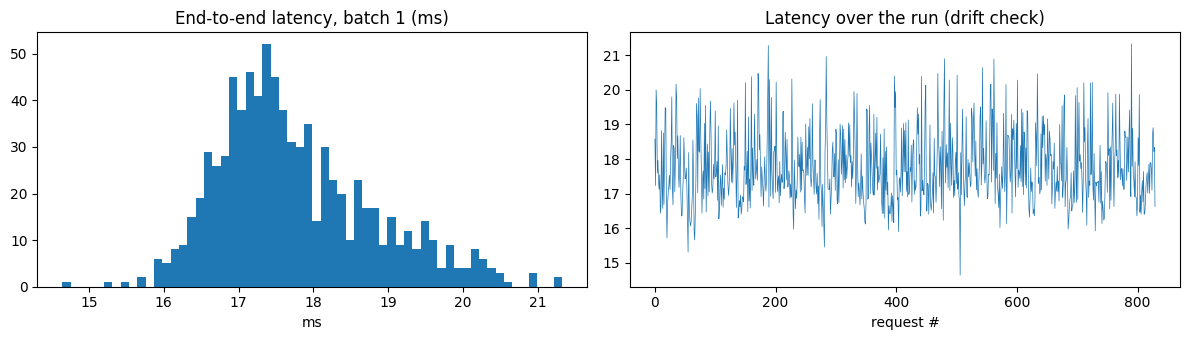

In [23]:
# S2. Repeated inference: every test image, REPEATS times, batch size 1, starting from the PNG on disk.
# This is the realistic "one part arrives, one decision" path.
REPEATS = 10

for p in all_test_paths[:10]:  # warm-up (cuDNN autotune, file cache)
    with torch.inference_mode(): bench_model(eval_transform(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE))
sync()
if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()

e2e_ms, model_ms, errors = [], [], 0
scores_by_repeat = np.zeros((REPEATS, len(all_test_paths)))
with GpuTelemetry() as tel_s2:
    t_wall = time.perf_counter()
    for r in range(REPEATS):
        for i, p in enumerate(all_test_paths):
            try:
                t0 = time.perf_counter()
                x = eval_transform(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
                sync(); t1 = time.perf_counter()
                with torch.inference_mode():
                    prob = torch.softmax(bench_model(x), 1)[0, 1].item()
                t2 = time.perf_counter()
                e2e_ms.append((t2 - t0) * 1000); model_ms.append((t2 - t1) * 1000)
                scores_by_repeat[r, i] = prob
            except Exception as exc:
                errors += 1; print("error:", p, exc)
    wall_s = time.perf_counter() - t_wall

BENCHMARK["repeated_inference"] = {
    "images": len(e2e_ms), "errors": errors, "wall_seconds": round(wall_s, 2),
    "throughput_img_per_s": round(len(e2e_ms) / wall_s, 1),
    "end_to_end_batch1": {k: round(v, 3) for k, v in latency_stats(e2e_ms).items()},
    "model_only_batch1": {k: round(v, 3) for k, v in latency_stats(model_ms).items()},
    "max_score_drift_across_repeats": float(scores_by_repeat.std(0).max()),
    "peak_gpu_mem_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1) if DEVICE.type == "cuda" else None,
}
print(json.dumps(BENCHMARK["repeated_inference"], indent=2))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(e2e_ms, bins=60); ax[0].set_title("End-to-end latency, batch 1 (ms)"); ax[0].set_xlabel("ms")
ax[1].plot(e2e_ms, lw=0.5); ax[1].set_title("Latency over the run (drift check)"); ax[1].set_xlabel("request #")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "s2_latency.png", dpi=120); plt.show()

,precision,batch_size,ms_per_batch,ms_per_image,images_per_s,p95_ms_per_batch,peak_mem_mb,status
0,fp32,1,1.334,1.3340,749.6,1.678,6240.8,ok
1,fp32,8,1.661,0.2076,4816.9,1.834,6243.3,ok
2,fp32,16,2.489,0.1556,6428.6,2.709,6261.8,ok
3,fp32,32,4.558,0.1424,7020.3,5.081,6295.8,ok
4,fp32,64,15.721,0.2456,4070.9,16.636,6375.8,ok
5,fp32,128,19.313,0.1509,6627.6,20.110,6481.8,ok
6,fp32,256,39.223,0.1532,6526.8,41.041,6737.8,ok
7,bf16,1,1.125,1.1253,888.7,1.490,6235.5,ok
8,bf16,8,1.388,0.1735,5764.4,1.530,6235.9,ok
9,bf16,16,1.804,0.1127,8871.1,2.094,6243.8,ok


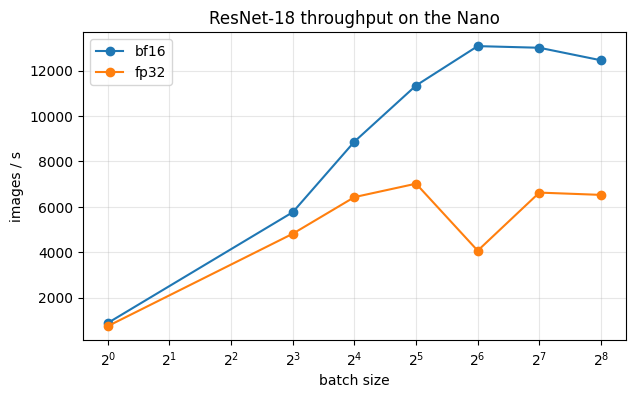

In [24]:
# S3. Batch-size sweep, fp32 vs bf16 autocast. Tensors are preloaded on the GPU, so this
# measures model throughput only (no disk or decode time).
BATCH_SIZES = [1, 8, 16, 32, 64, 128, 256]
ITERS = 30
base = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
pool = base.repeat((max(BATCH_SIZES) // len(base)) + 1, 1, 1, 1)[:max(BATCH_SIZES)].to(DEVICE)

sweep = []
for precision in ["fp32", "bf16"]:
    for bs in BATCH_SIZES:
        x = pool[:bs]
        try:
            if DEVICE.type == "cuda": torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
            ctx = (lambda: torch.autocast("cuda", dtype=torch.bfloat16)) if precision == "bf16" else (lambda: torch.autocast("cuda", enabled=False))
            with torch.inference_mode(), ctx():
                for _ in range(5): bench_model(x)          # warm-up
                sync(); times = []
                for _ in range(ITERS):
                    t0 = time.perf_counter(); bench_model(x); sync(); times.append((time.perf_counter() - t0) * 1000)
            ms = float(np.median(times))
            sweep.append({"precision": precision, "batch_size": bs, "ms_per_batch": round(ms, 3),
                          "ms_per_image": round(ms / bs, 4), "images_per_s": round(bs / ms * 1000, 1),
                          "p95_ms_per_batch": round(float(np.percentile(times, 95)), 3),
                          "peak_mem_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1) if DEVICE.type == "cuda" else None,
                          "status": "ok"})
        except torch.cuda.OutOfMemoryError:
            sweep.append({"precision": precision, "batch_size": bs, "status": "OOM"}); torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep); display(sweep_df)
sweep_df.to_csv(RESULTS_DIR / "s3_batch_sweep.csv", index=False)
best = sweep_df[sweep_df.status == "ok"].sort_values("images_per_s").iloc[-1]
BENCHMARK["batch_sweep"] = {"peak_images_per_s": float(best.images_per_s), "at_batch_size": int(best.batch_size),
                            "precision": best.precision, "oom_at": sweep_df[sweep_df.status == "OOM"].batch_size.tolist()}

fig, ax = plt.subplots(figsize=(7, 4))
for prec, g in sweep_df[sweep_df.status == "ok"].groupby("precision"):
    ax.plot(g.batch_size, g.images_per_s, marker="o", label=prec)
ax.set_xscale("log", base=2); ax.set_xlabel("batch size"); ax.set_ylabel("images / s"); ax.set_title("ResNet-18 throughput on the Nano")
ax.legend(); ax.grid(True, alpha=.3); plt.savefig(RESULTS_DIR / "s3_batch_sweep.png", dpi=120); plt.show()

,perturbation,roc_auc,recall,false_positive_rate,escapes_at_policy
0,none,0.993,0.968,0.05,2
1,darker (x0.6),0.977,1.000,0.60,0
2,brighter (x1.4),0.994,0.984,0.30,1
3,low contrast,0.938,0.984,0.80,1
4,blur (r=2),0.990,0.937,0.00,4
5,JPEG q=20,0.955,1.000,0.80,0
6,noise (sigma=12),0.989,0.968,0.05,2
7,rotate 5 deg,0.985,0.984,0.20,1
8,rotate 15 deg,0.978,1.000,1.00,0
9,crop 85%,0.952,1.000,0.95,0


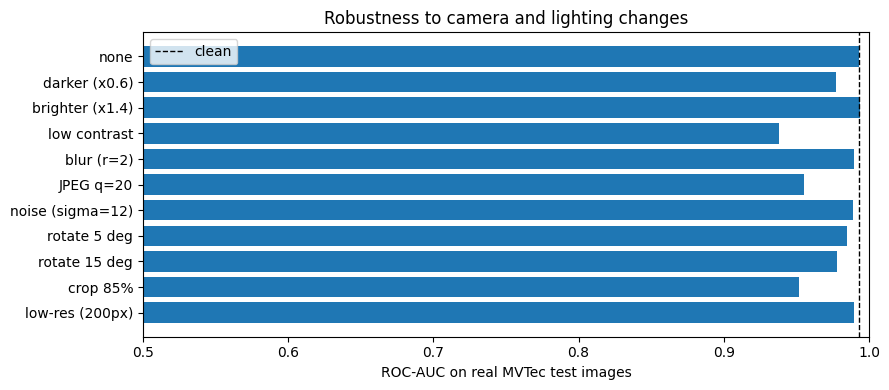

In [25]:
# S4. Input robustness: how much do metrics change under camera/lighting/compression changes?
from PIL import ImageEnhance, ImageFilter
import io

def jpeg(image, quality):
    buf = io.BytesIO(); image.save(buf, format="JPEG", quality=quality); buf.seek(0); return Image.open(buf).convert("RGB")

def gaussian_noise(image, sigma, rng=np.random.default_rng(SEED)):
    a = np.asarray(image, dtype=np.float32) + rng.normal(0, sigma, (image.size[1], image.size[0], 3))
    return Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))

def center_crop(image, frac):
    w, h = image.size; cw, ch = int(w * frac), int(h * frac)
    return image.crop(((w - cw) // 2, (h - ch) // 2, (w + cw) // 2, (h + ch) // 2))

PERTURBATIONS = {
    "none":            lambda im: im,
    "darker (x0.6)":   lambda im: ImageEnhance.Brightness(im).enhance(0.6),
    "brighter (x1.4)": lambda im: ImageEnhance.Brightness(im).enhance(1.4),
    "low contrast":    lambda im: ImageEnhance.Contrast(im).enhance(0.6),
    "blur (r=2)":      lambda im: im.filter(ImageFilter.GaussianBlur(2)),
    "JPEG q=20":       lambda im: jpeg(im, 20),
    "noise (sigma=12)":lambda im: gaussian_noise(im, 12),
    "rotate 5 deg":    lambda im: im.rotate(5),
    "rotate 15 deg":   lambda im: im.rotate(15),
    "crop 85%":        lambda im: center_crop(im, 0.85),
    "low-res (200px)": lambda im: im.resize((200, 200)).resize(im.size),
}

@torch.no_grad()
def score_images(pil_images, batch=32):
    out = []
    for i in range(0, len(pil_images), batch):
        x = torch.stack([eval_transform(im) for im in pil_images[i:i + batch]]).to(DEVICE)
        out.extend(torch.softmax(bench_model(x), 1)[:, 1].cpu().tolist())
    return np.array(out)

originals = [Image.open(p).convert("RGB") for p in all_test_paths]
labels = np.array([l for _, l, _ in all_test_items])
rob = []
for name, fn in PERTURBATIONS.items():
    s = score_images([fn(im) for im in originals])
    pred = s >= 0.5
    rob.append({"perturbation": name, "roc_auc": roc_auc_score(labels, s),
                "recall": pred[labels == 1].mean(), "false_positive_rate": pred[labels == 0].mean(),
                "escapes_at_policy": int(((s < DECISION_POLICY["review_at"]) & (labels == 1)).sum())})
rob_df = pd.DataFrame(rob).round(3); display(rob_df)
rob_df.to_csv(RESULTS_DIR / "s4_robustness.csv", index=False)
BENCHMARK["robustness"] = {"clean_auc": float(rob_df.roc_auc[0]), "worst_auc": float(rob_df.roc_auc.min()),
                           "worst_case": rob_df.perturbation[rob_df.roc_auc.idxmin()]}

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(rob_df.perturbation, rob_df.roc_auc); ax.axvline(rob_df.roc_auc[0], color="k", ls="--", lw=1, label="clean")
ax.set_xlim(0.5, 1.0); ax.set_xlabel("ROC-AUC on real MVTec test images"); ax.invert_yaxis(); ax.legend()
ax.set_title("Robustness to camera and lighting changes"); plt.tight_layout(); plt.savefig(RESULTS_DIR / "s4_robustness.png", dpi=120); plt.show()

In [26]:
# S5. Operating-point analysis. For a factory the key numbers are:
#   escapes       = defective parts that would be auto-accepted (reach the customer)
#   false rejects = good parts auto-rejected (scrap)
#   review load   = parts sent to a human
# DECISION_POLICY["review_at"] came from validation data. The sweep below is analysis, not tuning.
s, y = np.asarray(y_score), np.asarray(y_true)
rows = []
for review_at in sorted({0.1, 0.15, 0.2, 0.3, 0.4, 0.5, DECISION_POLICY["review_at"]}):
    accept = s < review_at; reject = s >= DECISION_POLICY["reject_at"]; review = ~accept & ~reject
    rows.append({"review_at": round(review_at, 3), "chosen_policy": abs(review_at - DECISION_POLICY["review_at"]) < 1e-9,
                 "escapes (defect accepted)": int((accept & (y == 1)).sum()),
                 "escape_rate": round((accept & (y == 1)).sum() / (y == 1).sum(), 3),
                 "false_rejects (good rejected)": int((reject & (y == 0)).sum()),
                 "manual_review_share": round(review.mean(), 3),
                 "good_parts_auto_accepted": int((accept & (y == 0)).sum())})
op_df = pd.DataFrame(rows); display(op_df)
op_df.to_csv(RESULTS_DIR / "s5_operating_points.csv", index=False)
BENCHMARK["decision_policy"] = {**DECISION_POLICY, **op_df[op_df.chosen_policy].drop(columns=["chosen_policy"]).iloc[0].to_dict()}
print("Escaped defects at chosen policy:")
display(results[(results.true_label == 1) & (results.anomaly_probability < DECISION_POLICY["review_at"])][["defect_type", "path", "anomaly_probability"]])

,review_at,chosen_policy,escapes (defect accepted),escape_rate,false_rejects (good rejected),manual_review_share,good_parts_auto_accepted
0,0.10,False,0,0.000,0,0.361,0
1,0.15,False,0,0.000,0,0.349,1
2,0.20,False,0,0.000,0,0.265,8
3,0.30,False,0,0.000,0,0.181,15
4,0.40,False,2,0.032,0,0.120,18
5,0.50,True,2,0.032,0,0.108,19


Escaped defects at chosen policy:


,defect_type,path,anomaly_probability
46,contamination,/home/hp14/jupyterlab/mvtec_anomaly_detection/...,0.316724
61,contamination,/home/hp14/jupyterlab/mvtec_anomaly_detection/...,0.317895


0.2 min | 4087 img/s | temp 57.0 C

0.3 min | 4089 img/s | temp 59.0 C

0.5 min | 4086 img/s | temp 61.0 C

0.7 min | 4081 img/s | temp 62.0 C

0.8 min | 4087 img/s | temp 64.0 C

...

14.3 min | 4081 img/s | temp 68.0 C

14.5 min | 4077 img/s | temp 67.0 C

14.7 min | 4078 img/s | temp 68.0 C

14.8 min | 4081 img/s | temp 68.0 C

15.0 min | 4082 img/s | temp 68.0 C
{
  "minutes": 15.0,
  "batch_size": 64,
  "total_images": 3674432,
  "mean_images_per_s": 4079.9,
  "throughput_change_first_to_last_pct": -0.15,
  "max_temp_c": 68.0,
  "mean_power_w": 53.8,
  "min_sm_clock_mhz": 2405.0,
  "max_sm_clock_mhz": 2496.0,
  "throttle_flag_seen": false,
  "peak_system_ram_gb": 28.7
}


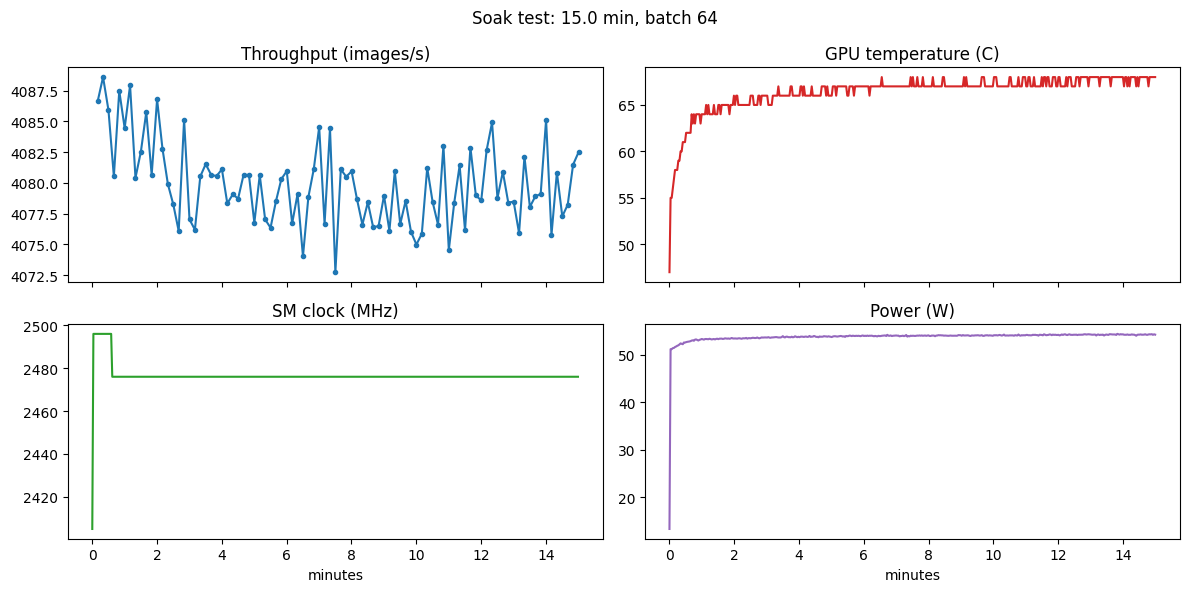

In [27]:
# S6. Soak test: keep the GPU saturated for SOAK_MINUTES and watch for thermal throttling.
# Default 15 min; set NANOINSPECT_SOAK_MINUTES=1 for a dry run. Watch `nvidia-smi` in a terminal.
SOAK_MINUTES = float(os.environ.get("NANOINSPECT_SOAK_MINUTES", 15))
SOAK_BATCH = 64
WINDOW_S = 10

x = pool[:SOAK_BATCH]
windows = []; total_images = 0
with GpuTelemetry(interval_s=2.0) as tel_soak:
    t_end = time.perf_counter() + SOAK_MINUTES * 60
    while time.perf_counter() < t_end:
        w0 = time.perf_counter(); n = 0; lat = []
        while time.perf_counter() - w0 < WINDOW_S:
            t0 = time.perf_counter()
            with torch.inference_mode(): bench_model(x)
            sync(); lat.append((time.perf_counter() - t0) * 1000); n += SOAK_BATCH
        total_images += n
        windows.append({"t_min": (time.perf_counter() - tel_soak.t0) / 60, "images_per_s": n / (time.perf_counter() - w0),
                        "p95_batch_ms": float(np.percentile(lat, 95))})
        print(f"\r{windows[-1]['t_min']:.1f} min | {windows[-1]['images_per_s']:.0f} img/s | "
              f"temp {tel_soak.rows[-1]['temp_c'] if tel_soak.rows else '?'} C", end="")
print()
win_df, tele = pd.DataFrame(windows), tel_soak.df
first, last = win_df.images_per_s.iloc[:3].mean(), win_df.images_per_s.iloc[-3:].mean()
BENCHMARK["soak"] = {"minutes": SOAK_MINUTES, "batch_size": SOAK_BATCH, "total_images": int(total_images),
                     "mean_images_per_s": round(float(win_df.images_per_s.mean()), 1),
                     "throughput_change_first_to_last_pct": round((last - first) / first * 100, 2),
                     "max_temp_c": float(tele.temp_c.max()), "mean_power_w": round(float(tele.power_w.mean()), 1),
                     "min_sm_clock_mhz": float(tele.sm_clock_mhz.min()), "max_sm_clock_mhz": float(tele.sm_clock_mhz.max()),
                     "throttle_flag_seen": bool(tele.throttle_active.any()),
                     "peak_system_ram_gb": round(float(tele.system_ram_used_gb.max()), 1)}
print(json.dumps(BENCHMARK["soak"], indent=2))
win_df.to_csv(RESULTS_DIR / "s6_soak_windows.csv", index=False); tele.to_csv(RESULTS_DIR / "s6_soak_telemetry.csv", index=False)

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
ax[0, 0].plot(win_df.t_min, win_df.images_per_s, marker="."); ax[0, 0].set_title("Throughput (images/s)")
ax[0, 1].plot(tele.t_s / 60, tele.temp_c, color="tab:red"); ax[0, 1].set_title("GPU temperature (C)")
ax[1, 0].plot(tele.t_s / 60, tele.sm_clock_mhz, color="tab:green"); ax[1, 0].set_title("SM clock (MHz)")
ax[1, 1].plot(tele.t_s / 60, tele.power_w, color="tab:purple"); ax[1, 1].set_title("Power (W)")
for a in ax[1]: a.set_xlabel("minutes")
plt.suptitle(f"Soak test: {SOAK_MINUTES} min, batch {SOAK_BATCH}"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "s6_soak.png", dpi=120); plt.show()

In [28]:
# S7. Agent load test: good and defective images (seeded stratified sample, not hand-picked)
# through the full local LLM agent. Also writes a JSONL audit log with one line per decision.
AGENT_N_GOOD, AGENT_N_DEFECT = 8, 16
rng = random.Random(SEED)
good_items = [it for it in all_test_items if it[1] == 0]
bad_items = [it for it in all_test_items if it[1] == 1]
agent_items = rng.sample(good_items, AGENT_N_GOOD) + rng.sample(bad_items, AGENT_N_DEFECT)
rng.shuffle(agent_items)

audit_path = RESULTS_DIR / "s7_audit_log.jsonl"
agent_rows = []
with open(audit_path, "w") as audit, GpuTelemetry() as tel_agent:
    for n, (path, label, defect) in enumerate(agent_items, 1):
        st = safe_run_inspection_agent(path, CATEGORY)
        rep, m = st["report"], st["metrics"]
        agent_rows.append({
            "image": f"{defect}/{Path(path).name}", "true_label": label,
            "vision_prob": st["vision_evidence"].get("anomaly_probability"),
            "decision": rep["decision"], "severity": rep["severity"],
            "escape": label == 1 and rep["decision"] == "accept",
            "false_reject": label == 0 and rep["decision"] == "reject",
            "schema_valid": not rep["schema_problems"], "llm_text_valid": rep["llm_text_valid"],
            "action_json_valid_rate": np.mean(m["llm_action_json_valid"]) if m["llm_action_json_valid"] else np.nan,
            "guardrail_overrides": m["guardrail_overrides"], "tool_calls": len(st["tool_trace"]),
            "llm_calls": m["llm_calls"], "llm_seconds": m["llm_seconds"], "total_seconds": m["total_seconds"],
            "error": st.get("error")})
        audit.write(json.dumps({"timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"), "image": path,
                                "report": {k: v for k, v in rep.items() if k != "raw_output"},
                                "tool_trace": st["tool_trace"]}, default=str) + "\n")
        print(f"\r{n}/{len(agent_items)} {agent_rows[-1]['image']:<28} -> {rep['decision']:<13} "
              f"({m['total_seconds']:.1f}s)", end="")
print()
agent_df = pd.DataFrame(agent_rows); display(agent_df)
agent_df.to_csv(RESULTS_DIR / "s7_agent_load.csv", index=False)

BENCHMARK["agent_load"] = {
    "images": len(agent_df), "good": AGENT_N_GOOD, "defective": AGENT_N_DEFECT, "llm": LLM_ID,
    "report_schema_valid_rate": float(agent_df.schema_valid.mean()),
    "llm_text_valid_rate": float(agent_df.llm_text_valid.mean()),
    "llm_fallback_rate": float(1 - agent_df.llm_text_valid.mean()),
    "llm_action_json_valid_rate": float(agent_df.action_json_valid_rate.mean()),
    "guardrail_overrides_per_image": float(agent_df.guardrail_overrides.mean()),
    "decisions": agent_df.decision.value_counts().to_dict(),
    "escapes": int(agent_df.escape.sum()), "false_rejects": int(agent_df.false_reject.sum()),
    "end_to_end_s": {k: round(v / 1000, 2) for k, v in latency_stats(agent_df.total_seconds * 1000).items() if k != "n"},
    "llm_s_per_call": round(float(agent_df.llm_seconds.sum() / agent_df.llm_calls.sum()), 2),
    "peak_system_ram_gb": round(float(tel_agent.df.system_ram_used_gb.max()), 1),
    "max_temp_c": float(tel_agent.df.temp_c.max()),
}
print(json.dumps(BENCHMARK["agent_load"], indent=2))
print("Audit log:", audit_path.resolve())

1/24 contamination/005.png        -> reject        (9.6s)

2/24 good/007.png                 -> accept        (9.0s)

3/24 contamination/015.png        -> reject        (9.6s)

4/24 broken_large/001.png         -> reject        (8.6s)

5/24 broken_large/002.png         -> reject        (9.2s)

...

22/24 broken_small/012.png         -> reject        (9.6s)

23/24 contamination/012.png        -> manual_review (10.1s)

24/24 good/011.png                 -> accept        (9.1s)


,image,true_label,vision_prob,decision,severity,escape,false_reject,schema_valid,llm_text_valid,action_json_valid_rate,guardrail_overrides,tool_calls,llm_calls,llm_seconds,total_seconds,error
0,contamination/005.png,1,0.9919,reject,high,False,False,True,True,1.0,2,5,6,9.521765,9.585088,None
1,good/007.png,0,0.2123,accept,low,False,False,True,True,1.0,3,5,6,8.907018,8.973317,None
2,contamination/015.png,1,0.9942,reject,high,False,False,True,True,1.0,2,5,6,9.562238,9.620664,None
3,broken_large/001.png,1,0.9900,reject,high,False,False,True,True,1.0,2,5,6,8.577208,8.637091,None
4,broken_large/002.png,1,0.9970,reject,high,False,False,True,True,1.0,2,5,6,9.089292,9.151628,None
5,broken_large/013.png,1,0.9997,reject,high,False,False,True,True,1.0,2,5,6,9.358349,9.419346,None
6,good/000.png,0,0.4099,accept,low,False,False,True,True,1.0,3,5,6,8.704061,8.758683,None
7,broken_large/014.png,1,0.9901,reject,high,False,False,True,True,1.0,2,5,6,9.390418,9.444835,None
8,good/016.png,0,0.2402,accept,low,False,False,True,True,1.0,3,5,6,8.605451,8.668477,None
9,good/002.png,0,0.3947,accept,low,False,False,True,True,1.0,3,5,6,8.564026,8.620724,None


{
  "images": 24,
  "good": 8,
  "defective": 16,
  "llm": "Qwen/Qwen2.5-3B-Instruct",
  "report_schema_valid_rate": 1.0,
  "llm_text_valid_rate": 1.0,
  "llm_fallback_rate": 0.0,
  "llm_action_json_valid_rate": 1.0,
  "guardrail_overrides_per_image": 2.375,
  "decisions": {
    "reject": 14,
    "accept": 8,
    "manual_review": 2
  },
  "escapes": 0,
  "false_rejects": 0,
  "end_to_end_s": {
    "p50_ms": 9.3,
    "p95_ms": 10.01,
    "p99_ms": 11.02,
    "mean_ms": 9.26,
    "max_ms": 11.3
  },
  "llm_s_per_call": 1.53,
  "peak_system_ram_gb": 28.2,
  "max_temp_c": 68.0
}
Audit log: /home/hp14/Downloads/working dir RR/stress_results/s7_audit_log.jsonl


In [29]:
# S8. Offline proof: block every outbound network connection from this Python process
# (DNS and sockets), force Hugging Face offline mode, then run the full pipeline.
# Any connection attempt is logged. The result should be zero attempts and every run completing.
# For the live demo, also physically disconnect Wi-Fi/Ethernet. If you are connected over
# SSH or VS Code Remote, disconnecting the network will end that session.
import socket

LOCAL_HOSTS = ("127.", "::1", "localhost", "0.0.0.0")
blocked_attempts = []
_real_connect, _real_getaddrinfo = socket.socket.connect, socket.getaddrinfo

def _is_local(host): return isinstance(host, str) and host.startswith(LOCAL_HOSTS)

def _guard_connect(self, address):
    if self.family == socket.AF_UNIX or _is_local(address[0]):
        return _real_connect(self, address)
    blocked_attempts.append(("connect", str(address))); raise OSError(f"[offline test] blocked connect to {address}")

def _guard_getaddrinfo(host, *args, **kwargs):
    if host is None or _is_local(host):
        return _real_getaddrinfo(host, *args, **kwargs)
    blocked_attempts.append(("dns", str(host))); raise socket.gaierror(f"[offline test] blocked DNS lookup for {host}")

saved_env = {k: os.environ.get(k) for k in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE"]}
offline_runs = []
try:
    socket.socket.connect, socket.getaddrinfo = _guard_connect, _guard_getaddrinfo
    os.environ["HF_HUB_OFFLINE"] = os.environ["TRANSFORMERS_OFFLINE"] = "1"

    # 1) Model weights load from local disk only
    AutoTokenizer.from_pretrained(LLM_ID, local_files_only=True)
    models.resnet18(weights=ResNet18_Weights.DEFAULT)
    # 2) Full agent pipeline on the three demo cases
    for title, path in DEMO_CASES.items():
        t0 = time.perf_counter(); st = safe_run_inspection_agent(path, CATEGORY)
        offline_runs.append({"case": title, "decision": st["report"]["decision"], "error": st.get("error"),
                             "llm_calls": st["metrics"]["llm_calls"], "seconds": round(time.perf_counter() - t0, 2)})
finally:
    socket.socket.connect, socket.getaddrinfo = _real_connect, _real_getaddrinfo
    for k, v in saved_env.items():
        if v is None: os.environ.pop(k, None)
        else: os.environ[k] = v

display(pd.DataFrame(offline_runs))
BENCHMARK["offline"] = {"runs": len(offline_runs), "runs_completed_without_error": sum(r["error"] is None for r in offline_runs),
                        "outbound_connection_attempts": len(blocked_attempts), "attempts": blocked_attempts[:10]}
print(json.dumps(BENCHMARK["offline"], indent=2))
assert all(r["error"] is None for r in offline_runs), "Pipeline failed while offline"
print("Offline proof passed: model loading and full agent runs completed with the network blocked.")

,case,decision,error,llm_calls,seconds
0,Good part (lowest score),accept,None,6,9.94
1,Clear defect (highest score),reject,None,6,8.96
2,Borderline defect (closest to 0.5),manual_review,None,6,11.02


{
  "runs": 3,
  "runs_completed_without_error": 3,
  "outbound_connection_attempts": 0,
  "attempts": []
}
Offline proof passed: model loading and full agent runs completed with the network blocked.


In [30]:
# S9. Failure recovery: broken inputs and a broken LLM must never produce "accept" and must never crash.
fail_dir = RESULTS_DIR / "failure_inputs"; fail_dir.mkdir(exist_ok=True)
good_example = next(p for p, l, _ in all_test_items if l == 0)
(fail_dir / "random_bytes.png").write_bytes(os.urandom(4096))
(fail_dir / "truncated.png").write_bytes(Path(good_example).read_bytes()[:20000])
Image.new("RGB", (900, 900), (0, 0, 0)).save(fail_dir / "all_black.png")
Image.new("RGB", (900, 900), (255, 255, 255)).save(fail_dir / "all_white.png")
Image.fromarray(np.random.default_rng(SEED).integers(0, 255, (900, 900, 3), dtype=np.uint8)).save(fail_dir / "pure_noise.png")

cases = [("missing file", fail_dir / "does_not_exist.png"), ("random bytes", fail_dir / "random_bytes.png"),
         ("truncated PNG", fail_dir / "truncated.png"), ("all-black frame (lens cap)", fail_dir / "all_black.png"),
         ("all-white frame (overexposed)", fail_dir / "all_white.png"), ("pure noise", fail_dir / "pure_noise.png")]
fail_rows = []
for name, path in cases:
    st = safe_run_inspection_agent(path, CATEGORY)
    fail_rows.append({"case": name, "decision": st["report"]["decision"], "schema_valid": not st["report"]["schema_problems"],
                      "handled_as": (st.get("error") or st.get("input_override") or f"model decision (z={st.get('input_check', {}).get('z')})")[:90]})

# LLM failures: garbage text, and an exception (e.g., CUDA out of memory)
_real_generate = generate_local_llm
for name, fake in [("LLM returns malformed text", lambda *a, **k: "Sure! {decision: accept,,, ]]"),
                   ("LLM raises an exception", lambda *a, **k: (_ for _ in ()).throw(RuntimeError("simulated CUDA OOM")))]:
    generate_local_llm = fake
    try:
        st = safe_run_inspection_agent(DEMO_CASES["Clear defect (highest score)"], CATEGORY)
    finally:
        generate_local_llm = _real_generate
    fail_rows.append({"case": name + " (clear defect image)", "decision": st["report"]["decision"],
                      "schema_valid": not st["report"]["schema_problems"],
                      "handled_as": f"deterministic fallback; llm_fallback_used={st['report']['llm_fallback_used']}"})

fail_df = pd.DataFrame(fail_rows); display(fail_df)
fail_df.to_csv(RESULTS_DIR / "s9_failure_recovery.csv", index=False)
BENCHMARK["failure_recovery"] = {"cases": len(fail_df), "all_schema_valid": bool(fail_df.schema_valid.all()),
                                 "any_silent_accept": bool((fail_df.decision == "accept").any())}
assert not BENCHMARK["failure_recovery"]["any_silent_accept"], "A broken input was accepted"
assert BENCHMARK["failure_recovery"]["all_schema_valid"]
print("Failure recovery passed: no crash, no silent accept, every report valid.")

,case,decision,schema_valid,handled_as
0,missing file,manual_review,True,unreadable image (FileNotFoundError: [Errno 2]...
1,random bytes,manual_review,True,unreadable image (UnidentifiedImageError: cann...
2,truncated PNG,manual_review,True,unreadable image (OSError: image file is trunc...
3,all-black frame (lens cap),manual_review,True,"model decision (z=[98.4800033569336, 173.11999..."
4,all-white frame (overexposed),manual_review,True,"model decision (z=[85.75, 173.1199951171875])"
5,pure noise,manual_review,True,"model decision (z=[6.78000020980835, 162.52000..."
6,LLM returns malformed text (clear defect image),reject,True,deterministic fallback; llm_fallback_used=True
7,LLM raises an exception (clear defect image),reject,True,deterministic fallback; llm_fallback_used=True


Failure recovery passed: no crash, no silent accept, every report valid.


In [31]:
# S10. Edge vs cloud: how much data would leave the plant if every image went to a cloud API?
# Edit the assumptions for the factory you pitch. Only local latency is *measured* here;
# we did not call a cloud API, so no cloud latency is claimed.
PARTS_PER_MINUTE = 60        # assumption: line speed
HOURS_PER_DAY = 16           # assumption: two shifts
avg_image_mb = np.mean([Path(p).stat().st_size for p in all_test_paths]) / 1e6
images_per_day = PARTS_PER_MINUTE * 60 * HOURS_PER_DAY
takt_ms = 60_000 / PARTS_PER_MINUTE
local_p95_ms = BENCHMARK["repeated_inference"]["end_to_end_batch1"]["p95_ms"]
agent_p95_ms = BENCHMARK.get("agent_load", {}).get("end_to_end_s", {}).get("p95_ms", np.nan) * 1000

BENCHMARK["edge_vs_cloud"] = {
    "assumed_parts_per_minute": PARTS_PER_MINUTE, "assumed_hours_per_day": HOURS_PER_DAY,
    "avg_image_mb": round(avg_image_mb, 3), "images_per_day": images_per_day,
    "cloud_upload_gb_per_day": round(images_per_day * avg_image_mb / 1000, 1),
    "edge_upload_gb_per_day": 0.0,
    "takt_time_ms": takt_ms,
    "vision_p95_ms": round(local_p95_ms, 2), "vision_headroom_x": round(takt_ms / local_p95_ms, 1),
    "full_agent_p95_ms": round(agent_p95_ms, 0),
}
display(pd.DataFrame([
    ["Raw images leaving the plant per day", f"{BENCHMARK['edge_vs_cloud']['cloud_upload_gb_per_day']} GB", "0 GB"],
    ["Works if the WAN/Internet is down", "No", "Yes (S8)"],
    ["Vision decision latency (p95)", "network RTT + API time (not measured)", f"{local_p95_ms:.1f} ms"],
    ["Full agent report latency (p95)", "not measured", f"{agent_p95_ms/1000:.1f} s"],
    ["Per-image inference cost", "per-call API pricing", "fixed hardware, $0 per image"],
], columns=["", "Cloud API", "NanoInspect on ZGX Nano"]))
print(f"Line takt time {takt_ms:.0f} ms -> vision path has {takt_ms / local_p95_ms:.0f}x headroom.")
print("Note: the full LLM report is slower than takt time. Run it only on parts that are not a clear accept, or asynchronously.")

,,Cloud API,NanoInspect on ZGX Nano
0,Raw images leaving the plant per day,30.9 GB,0 GB
1,Works if the WAN/Internet is down,No,Yes (S8)
2,Vision decision latency (p95),network RTT + API time (not measured),19.8 ms
3,Full agent report latency (p95),not measured,10.0 s
4,Per-image inference cost,per-call API pricing,"fixed hardware, $0 per image"


Line takt time 1000 ms -> vision path has 51x headroom.
Note: the full LLM report is slower than takt time. Run it only on parts that are not a clear accept, or asynchronously.


In [32]:
# S11. Benchmark summary: one table for the slides, saved to stress_results/benchmark_summary.json
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = f"{prefix}{k}"
        if isinstance(v, dict): out.update(flatten(v, key + "."))
        elif not isinstance(v, list): out[key] = v
    return out

BENCHMARK["vision_metrics_real_test"] = {k: round(float(v), 4) for k, v in metrics.items()}
BENCHMARK["training"] = {"epochs": EPOCHS, "selected_epoch": best_epoch, "train_seconds": round(train_seconds, 1),
                         "train_images": len(normal_paths), "val_images": len(val_ds)}
(RESULTS_DIR / "benchmark_summary.json").write_text(json.dumps(BENCHMARK, indent=2, default=str))

slide = [
    ("Real-defect ROC-AUC (83 MVTec test images)", f"{metrics['roc_auc']:.3f}"),
    ("Recall / precision at 0.5", f"{metrics['recall']:.3f} / {metrics['precision']:.3f}"),
    ("Escapes at decision policy", f"{BENCHMARK['decision_policy']['escapes (defect accepted)']} of {int(sum(y_true))} defects"),
    ("Manual-review share", f"{BENCHMARK['decision_policy']['manual_review_share']:.1%}"),
    ("Vision latency, batch 1, from disk (p50 / p95)", f"{BENCHMARK['repeated_inference']['end_to_end_batch1']['p50_ms']:.1f} / {BENCHMARK['repeated_inference']['end_to_end_batch1']['p95_ms']:.1f} ms"),
    ("Peak GPU throughput", f"{BENCHMARK['batch_sweep']['peak_images_per_s']:,.0f} img/s (bs={BENCHMARK['batch_sweep']['at_batch_size']}, {BENCHMARK['batch_sweep']['precision']})"),
    (f"Soak test ({BENCHMARK['soak']['minutes']} min)", f"{BENCHMARK['soak']['total_images']:,} images, throughput change {BENCHMARK['soak']['throughput_change_first_to_last_pct']:+.1f}%, max {BENCHMARK['soak']['max_temp_c']:.0f} C, throttle flag: {BENCHMARK['soak']['throttle_flag_seen']}"),
    ("Worst robustness case", f"{BENCHMARK['robustness']['worst_case']} (AUC {BENCHMARK['robustness']['worst_auc']:.3f})"),
]
if "agent_load" in BENCHMARK:
    a = BENCHMARK["agent_load"]
    slide += [("Agent: valid reports", f"{a['report_schema_valid_rate']:.0%} of {a['images']}"),
              ("Agent: LLM text valid / fallback", f"{a['llm_text_valid_rate']:.0%} / {a['llm_fallback_rate']:.0%}"),
              ("Agent: end-to-end p50 / p95", f"{a['end_to_end_s']['p50_ms']:.1f} / {a['end_to_end_s']['p95_ms']:.1f} s")]
if "offline" in BENCHMARK:
    slide.append(("Offline run (network blocked)", f"{BENCHMARK['offline']['runs_completed_without_error']}/{BENCHMARK['offline']['runs']} completed, {BENCHMARK['offline']['outbound_connection_attempts']} connection attempts"))
if "failure_recovery" in BENCHMARK:
    slide.append(("Failure cases", f"{BENCHMARK['failure_recovery']['cases']} tested, silent accepts: {BENCHMARK['failure_recovery']['any_silent_accept']}"))
slide_df = pd.DataFrame(slide, columns=["Metric", "Result"])
display(slide_df)
try:
    table_text = slide_df.to_markdown(index=False)
except ImportError:
    table_text = slide_df.to_string(index=False)
(RESULTS_DIR / "benchmark_table.md").write_text(table_text)
print("Saved:", sorted(p.name for p in RESULTS_DIR.iterdir()))

,Metric,Result
0,Real-defect ROC-AUC (83 MVTec test images),0.993
1,Recall / precision at 0.5,0.968 / 0.984
2,Escapes at decision policy,2.0 of 63 defects
3,Manual-review share,10.8%
4,"Vision latency, batch 1, from disk (p50 / p95)",17.5 / 19.8 ms
5,Peak GPU throughput,"13,076 img/s (bs=64, bf16)"
6,Soak test (15.0 min),"3,674,432 images, throughput change -0.1%, max..."
7,Worst robustness case,low contrast (AUC 0.938)
8,Agent: valid reports,100% of 24
9,Agent: LLM text valid / fallback,100% / 0%


Saved: ['benchmark_summary.json', 'benchmark_table.md', 'failure_inputs', 's2_latency.png', 's3_batch_sweep.csv', 's3_batch_sweep.png', 's4_robustness.csv', 's4_robustness.png', 's5_operating_points.csv', 's6_soak.png', 's6_soak_telemetry.csv', 's6_soak_windows.csv', 's7_agent_load.csv', 's7_audit_log.jsonl', 's9_failure_recovery.csv']


## 9. Operator demo
A minimal local web screen for the live demo: upload a photo and get the decision, Grad-CAM, and report. It binds to `127.0.0.1` only, so nothing is exposed on the network. Run it after the benchmark is done.

In [33]:
import gradio as gr

DECISION_COLORS = {"accept": "#1a7f37", "reject": "#cf222e", "manual_review": "#9a6700"}

def operator_inspect(image_path):
    if image_path is None:
        return None, "<p>Upload an image.</p>", {}
    st = safe_run_inspection_agent(image_path, CATEGORY)
    rep = st["report"]
    overlay = None
    try:
        x = eval_transform(Image.open(image_path).convert("RGB"))
        _, cam = cam_generator(x.unsqueeze(0).to(DEVICE).requires_grad_(True), class_idx=1)
        heat = (plt.cm.jet(cam)[..., :3] * 255).astype(np.uint8)
        overlay = Image.blend(Image.fromarray((denormalize(x) * 255).astype(np.uint8)), Image.fromarray(heat), 0.45).resize((384, 384))
    except Exception:
        pass
    badge = (f"<h2 style='color:{DECISION_COLORS[rep['decision']]}'>{rep['decision'].upper().replace('_', ' ')}</h2>"
             f"<p><b>Severity:</b> {rep['severity']} &nbsp; <b>Anomaly probability:</b> "
             f"{st['vision_evidence'].get('anomaly_probability', 'n/a')} &nbsp; <b>Time:</b> {st['metrics']['total_seconds']:.1f}s</p>"
             f"<p><b>Action:</b> {rep['recommended_action']}</p><p>{rep['defect_summary']}</p>")
    return overlay, badge, {k: v for k, v in rep.items() if k != "raw_output"}

demo = gr.Interface(fn=operator_inspect, inputs=gr.Image(type="filepath", label="Part image"),
                    outputs=[gr.Image(label="Grad-CAM evidence"), gr.HTML(label="Decision"), gr.JSON(label="Audit report")],
                    title="NanoInspect: local quality inspection",
                    description="Runs entirely on the HP ZGX Nano. No image leaves this machine.",
                    examples=[[p] for p in DEMO_CASES.values()], flagging_mode="never")
demo.launch(server_name="127.0.0.1", server_port=7860, share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
